<a href="https://colab.research.google.com/github/anapaulachr23-star/segmentacao-clientes-unsupervised-ml/blob/main/Atividade_1_Ana_Rodrigues.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Atividade Prática: Segmentação de Clientes com Aprendizado Não Supervisionado

**Aluna:** Ana Rodrigues
**Dataset:** UCI Online Retail Dataset
**Objetivo:** Aplicar técnicas de aprendizado não supervisionado para segmentar clientes de um e-commerce e identificar padrões de comportamento e valor.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Online Retail.xlsx to Online Retail.xlsx


In [3]:
df = pd.read_excel('Online Retail.xlsx')

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
# Dimensões do dataset
print(f"Linhas: {df.shape[0]:,}")
print(f"Colunas: {df.shape[1]}")

# Informações gerais
df.info()

Linhas: 541,909
Colunas: 8
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [5]:
# Estatísticas descritivas das variáveis numéricas
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [6]:
# Quantidade de valores ausentes por coluna
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [7]:
# Percentual de valores ausentes
(df.isnull().mean() * 100).sort_values(ascending=False)

,0
CustomerID,24.926694
Description,0.268311
StockCode,0.000000
InvoiceNo,0.000000
Quantity,0.000000
InvoiceDate,0.000000
UnitPrice,0.000000
Country,0.000000


In [8]:
print(f"Quantidade de registros duplicados: {df.duplicated().sum():,}")

Quantidade de registros duplicados: 5,268


In [9]:
print(f"Total de transações: {len(df):,}")
print(f"Cancelamentos: {df['InvoiceNo'].astype(str).str.startswith('C').sum():,}")

Total de transações: 541,909
Cancelamentos: 9,288


In [10]:
print(f"Quantidade negativa: {(df['Quantity'] < 0).sum():,}")
print(f"Preço unitário igual a zero: {(df['UnitPrice'] == 0).sum():,}")

Quantidade negativa: 10,624
Preço unitário igual a zero: 2,515


In [11]:
# Comparação entre quantidade negativa e cancelamentos

negative_quantity = df['Quantity'] < 0
cancelled_invoice = df['InvoiceNo'].astype(str).str.startswith('C')

print("Quantidade negativa:")
print(negative_quantity.sum())

print("\nQuantidade negativa que também é cancelamento:")
print((negative_quantity & cancelled_invoice).sum())

print("\nQuantidade negativa que NÃO é cancelamento:")
print((negative_quantity & ~cancelled_invoice).sum())

Quantidade negativa:
10624

Quantidade negativa que também é cancelamento:
9288

Quantidade negativa que NÃO é cancelamento:
1336


In [12]:
# Características dos registros com UnitPrice = 0

zero_price = df[df['UnitPrice'] == 0]

print(f"Registros com preço zero: {len(zero_price):,}")
print(f"Clientes identificados: {zero_price['CustomerID'].notna().sum():,}")
print(f"Clientes não identificados: {zero_price['CustomerID'].isna().sum():,}")

zero_price.head(10)

Registros com preço zero: 2,515
Clientes identificados: 40
Clientes não identificados: 2,475


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom


## 6. Data Cleaning and Preprocessing

A etapa de pré-processamento foi realizada com o objetivo de construir uma base
consistente de transações de compra para a análise RFM e posterior aplicação
dos algoritmos de clusterização.

Foram identificados valores ausentes em CustomerID, registros duplicados,
cancelamentos, quantidades negativas e transações com preço unitário igual a
zero. Como a análise busca segmentar clientes com base em seu comportamento
de compra, foram mantidas apenas transações associadas a clientes identificados
e com quantidade e valor unitário positivos.

In [13]:
# Cópia do dataset original
df_clean = df.copy()

# 1. Remover registros duplicados
df_clean = df_clean.drop_duplicates()

# 2. Manter apenas transações com CustomerID identificado
df_clean = df_clean.dropna(subset=['CustomerID'])

# 3. Remover cancelamentos
df_clean = df_clean[
    ~df_clean['InvoiceNo'].astype(str).str.startswith('C')
]

# 4. Manter apenas quantidades positivas
df_clean = df_clean[df_clean['Quantity'] > 0]

# 5. Manter apenas preços unitários positivos
df_clean = df_clean[df_clean['UnitPrice'] > 0]

# 6. Criar valor total da transação
df_clean['TotalAmount'] = (
    df_clean['Quantity'] * df_clean['UnitPrice']
)

print(f"Registros antes da limpeza: {len(df):,}")
print(f"Registros após a limpeza: {len(df_clean):,}")
print(f"Registros removidos: {len(df) - len(df_clean):,}")

Registros antes da limpeza: 541,909
Registros após a limpeza: 392,692
Registros removidos: 149,217


In [14]:
# Validação da base após a limpeza

print("Valores ausentes:")
print(df_clean.isnull().sum())

print("\nQuantidade <= 0:")
print((df_clean['Quantity'] <= 0).sum())

print("\nUnitPrice <= 0:")
print((df_clean['UnitPrice'] <= 0).sum())

print("\nCancelamentos:")
print(
    df_clean['InvoiceNo']
    .astype(str)
    .str.startswith('C')
    .sum()
)

print("\nDuplicados:")
print(df_clean.duplicated().sum())

print("\nCustomerID ausente:")
print(df_clean['CustomerID'].isna().sum())

print("\nTotalAmount <= 0:")
print((df_clean['TotalAmount'] <= 0).sum())

Valores ausentes:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalAmount    0
dtype: int64

Quantidade <= 0:
0

UnitPrice <= 0:
0

Cancelamentos:
0

Duplicados:
0

CustomerID ausente:
0

TotalAmount <= 0:
0


In [15]:
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  int64         
 7   Country      392692 non-null  object        
 8   TotalAmount  392692 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 30.0+ MB


In [16]:
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

print("Última data da base:", df_clean['InvoiceDate'].max())
print("Data de referência:", reference_date)

Última data da base: 2011-12-09 12:50:00
Data de referência: 2011-12-10 12:50:00


In [17]:
rfm = df_clean.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalAmount', 'sum')
).reset_index()

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [18]:
print(f"Número de clientes na análise RFM: {rfm['CustomerID'].nunique():,}")

rfm.describe()

Número de clientes na análise RFM: 4,338


,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.688081
std,1721.808492,100.014169,7.697998,8985.230220
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,306.482500
50%,15299.500000,51.000000,2.000000,668.570000
75%,16778.750000,142.000000,5.000000,1660.597500
max,18287.000000,374.000000,209.000000,280206.020000


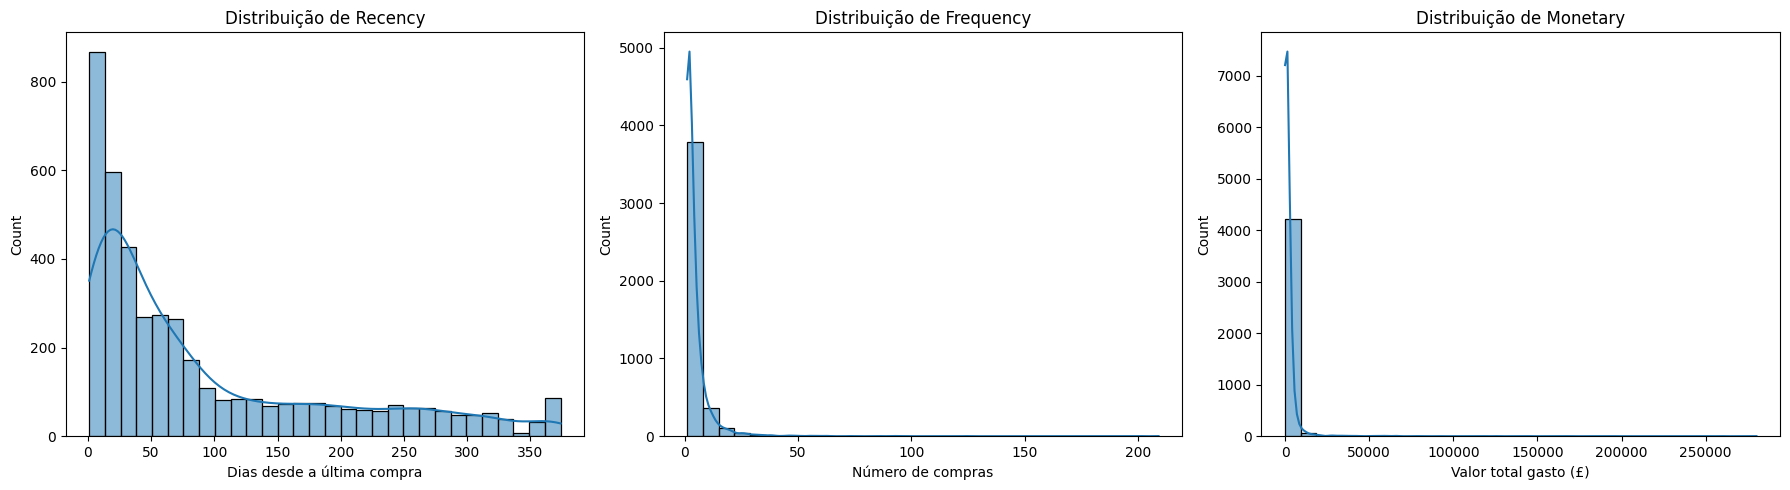

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm['Recency'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribuição de Recency')
axes[0].set_xlabel('Dias desde a última compra')

sns.histplot(rfm['Frequency'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Distribuição de Frequency')
axes[1].set_xlabel('Número de compras')

sns.histplot(rfm['Monetary'], bins=30, kde=True, ax=axes[2])
axes[2].set_title('Distribuição de Monetary')
axes[2].set_xlabel('Valor total gasto (£)')

plt.tight_layout()
plt.show()

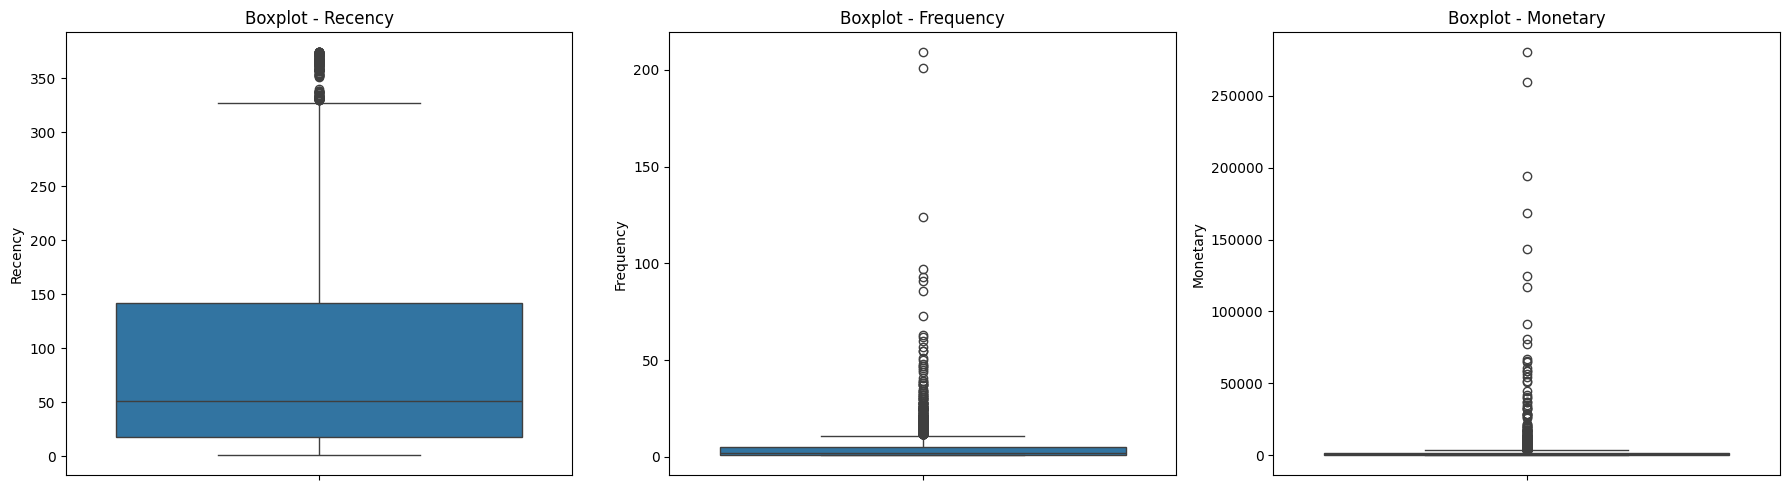

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(y=rfm['Recency'], ax=axes[0])
axes[0].set_title('Boxplot - Recency')

sns.boxplot(y=rfm['Frequency'], ax=axes[1])
axes[1].set_title('Boxplot - Frequency')

sns.boxplot(y=rfm['Monetary'], ax=axes[2])
axes[2].set_title('Boxplot - Monetary')

plt.tight_layout()
plt.show()

In [21]:
rfm_model = rfm.copy()

rfm_model['Recency'] = np.log1p(rfm_model['Recency'])
rfm_model['Frequency'] = np.log1p(rfm_model['Frequency'])
rfm_model['Monetary'] = np.log1p(rfm_model['Monetary'])

rfm_model.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,5.789960,0.693147,11.253955
1,12347,1.098612,2.079442,8.368925
2,12348,4.330733,1.609438,7.494564
3,12349,2.995732,0.693147,7.472245
4,12350,5.739793,0.693147,5.815324


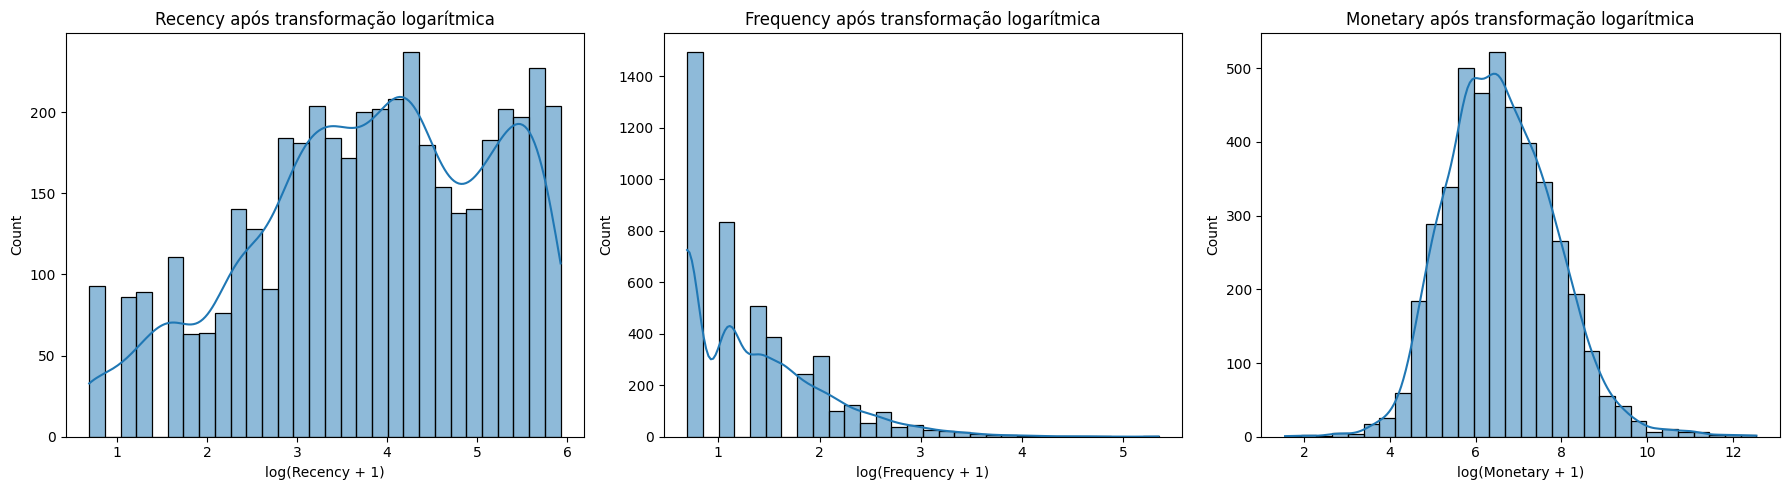

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm_model['Recency'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Recency após transformação logarítmica')
axes[0].set_xlabel('log(Recency + 1)')

sns.histplot(rfm_model['Frequency'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Frequency após transformação logarítmica')
axes[1].set_xlabel('log(Frequency + 1)')

sns.histplot(rfm_model['Monetary'], bins=30, kde=True, ax=axes[2])
axes[2].set_title('Monetary após transformação logarítmica')
axes[2].set_xlabel('log(Monetary + 1)')

plt.tight_layout()
plt.show()

In [23]:
skew_comparison = pd.DataFrame({
    'Variável': ['Recency', 'Frequency', 'Monetary'],
    'Assimetria antes': [
        rfm['Recency'].skew(),
        rfm['Frequency'].skew(),
        rfm['Monetary'].skew()
    ],
    'Assimetria depois': [
        rfm_model['Recency'].skew(),
        rfm_model['Frequency'].skew(),
        rfm_model['Monetary'].skew()
    ]
})

skew_comparison

,Variável,Assimetria antes,Assimetria depois
0,Recency,1.246048,-0.379169
1,Frequency,12.067031,1.208652
2,Monetary,19.339368,0.396599


In [24]:
from sklearn.preprocessing import StandardScaler

features = ['Recency', 'Frequency', 'Monetary']

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_model[features])

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=features,
    index=rfm_model.index
)

rfm_scaled.head()

,Recency,Frequency,Monetary
0,1.461993,-0.955214,3.707716
1,-2.038734,1.074425,1.414903
2,0.373104,0.386304,0.720024
3,-0.623086,-0.955214,0.702287
4,1.424558,-0.955214,-0.614514


In [25]:
rfm_scaled.describe()

,Recency,Frequency,Monetary
count,4.338000e+03,4.338000e+03,4.338000e+03
mean,-9.172520e-17,-7.206980e-17,-3.669008e-16
std,1.000115e+00,1.000115e+00,1.000115e+00
min,-2.341296e+00,-9.552143e-01,-3.997811e+00
25%,-6.613615e-01,-9.552143e-01,-6.835802e-01
50%,8.992557e-02,-3.615828e-01,-6.510929e-02
75%,8.447915e-01,6.532370e-01,6.572178e-01
max,1.564198e+00,5.858535e+00,4.732381e+00


In [26]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(rfm_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(rfm_scaled, labels)
    )

results_kmeans = pd.DataFrame({
    'K': list(k_values),
    'Inertia': inertias,
    'Silhouette': silhouette_scores
})

results_kmeans

,K,Inertia,Silhouette
0,2,6483.589425,0.432827
1,3,4869.488629,0.336517
2,4,3939.049382,0.337517
3,5,3296.708708,0.316200
4,6,2855.764068,0.312409
5,7,2548.820245,0.309186
6,8,2336.341054,0.303275
7,9,2156.005673,0.281085
8,10,2005.746236,0.276659


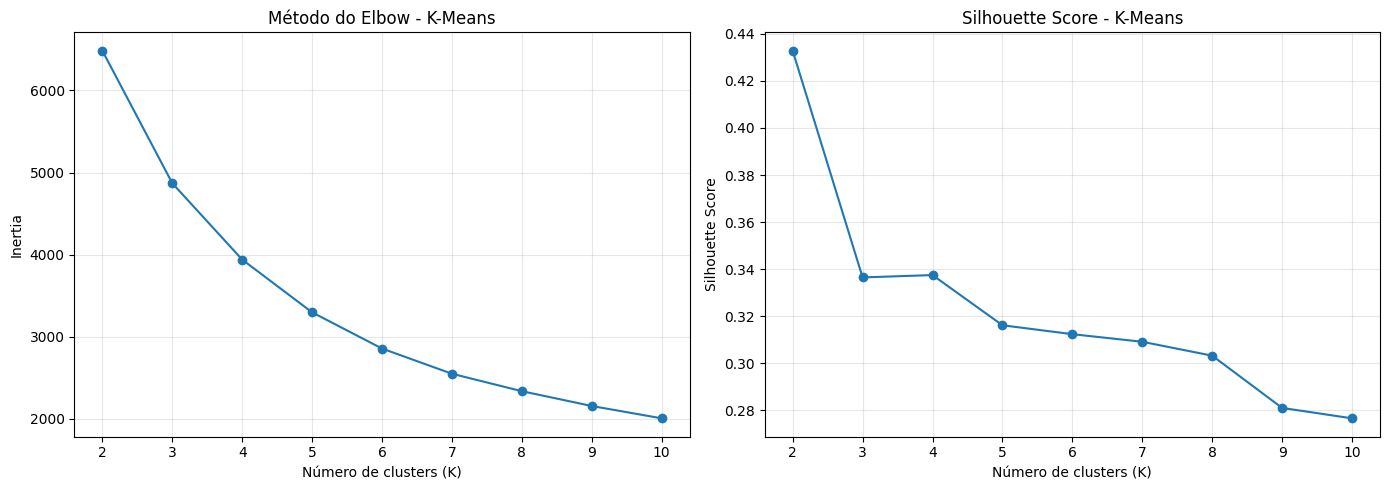

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(results_kmeans['K'], results_kmeans['Inertia'], marker='o')
axes[0].set_title('Método do Elbow - K-Means')
axes[0].set_xlabel('Número de clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(results_kmeans['K'])
axes[0].grid(True, alpha=0.3)

# Silhouette
axes[1].plot(results_kmeans['K'], results_kmeans['Silhouette'], marker='o')
axes[1].set_title('Silhouette Score - K-Means')
axes[1].set_xlabel('Número de clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(results_kmeans['K'])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
import time

start_time = time.time()

kmeans_final = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans_final.fit_predict(rfm_scaled)

execution_time = time.time() - start_time

kmeans_silhouette = silhouette_score(rfm_scaled, kmeans_labels)
kmeans_db = davies_bouldin_score(rfm_scaled, kmeans_labels)
kmeans_ch = calinski_harabasz_score(rfm_scaled, kmeans_labels)

print(f"Inertia: {kmeans_final.inertia_:.2f}")
print(f"Silhouette Score: {kmeans_silhouette:.4f}")
print(f"Davies-Bouldin Index: {kmeans_db:.4f}")
print(f"Calinski-Harabasz Score: {kmeans_ch:.2f}")
print(f"Tempo de execução: {execution_time:.4f} segundos")

Inertia: 3939.05
Silhouette Score: 0.3375
Davies-Bouldin Index: 1.0086
Calinski-Harabasz Score: 3328.34
Tempo de execução: 0.1102 segundos


In [29]:
rfm['KMeans_Cluster'] = kmeans_labels

rfm.head()

,CustomerID,Recency,Frequency,Monetary,KMeans_Cluster
0,12346,326,1,77183.60,3
1,12347,2,7,4310.00,0
2,12348,75,4,1797.24,3
3,12349,19,1,1757.55,2
4,12350,310,1,334.40,1


In [30]:
cluster_sizes = rfm['KMeans_Cluster'].value_counts().sort_index()

print("Quantidade de clientes por cluster:")
print(cluster_sizes)

print("\nPercentual de clientes por cluster:")
print((cluster_sizes / len(rfm) * 100).round(2))

Quantidade de clientes por cluster:
KMeans_Cluster
0     713
1    1622
2     837
3    1166
Name: count, dtype: int64

Percentual de clientes por cluster:
KMeans_Cluster
0    16.44
1    37.39
2    19.29
3    26.88
Name: count, dtype: float64


In [31]:
cluster_profile = rfm.groupby('KMeans_Cluster')[['Recency', 'Frequency', 'Monetary']].agg(
    ['mean', 'median']
).round(2)

cluster_profile

Recency        Frequency        Monetary         
                  mean median      mean median     mean   median
KMeans_Cluster                                                  
0                12.17    8.0     13.75   10.0  8088.02  3722.82
1               181.51  174.5      1.32    1.0   341.00   296.09
2                17.70   17.0      2.19    2.0   557.32   480.31
3                71.64   57.0      4.08    4.0  1801.78  1345.20

In [32]:
cluster_means = rfm.groupby('KMeans_Cluster')[[
    'Recency', 'Frequency', 'Monetary'
]].mean().round(2)

cluster_means

,Recency,Frequency,Monetary
KMeans_Cluster,,,
0,12.17,13.75,8088.02
1,181.51,1.32,341.00
2,17.70,2.19,557.32
3,71.64,4.08,1801.78


In [33]:
cluster_business = rfm.groupby('KMeans_Cluster').agg(
    Clientes=('CustomerID', 'count'),
    Recency_Media=('Recency', 'mean'),
    Frequency_Media=('Frequency', 'mean'),
    Monetary_Medio=('Monetary', 'mean'),
    Receita_Total=('Monetary', 'sum')
).round(2)

cluster_business['% da Receita'] = (
    cluster_business['Receita_Total'] /
    cluster_business['Receita_Total'].sum() * 100
).round(2)

cluster_business['% dos Clientes'] = (
    cluster_business['Clientes'] /
    cluster_business['Clientes'].sum() * 100
).round(2)

cluster_business

,Clientes,Recency_Media,Frequency_Media,Monetary_Medio,Receita_Total,% da Receita,% dos Clientes
KMeans_Cluster,,,,,,,
0,713,12.17,13.75,8088.02,5766757.07,64.89,16.44
1,1622,181.51,1.32,341.00,553099.77,6.22,37.39
2,837,17.70,2.19,557.32,466479.03,5.25,19.29
3,1166,71.64,4.08,1801.78,2100873.02,23.64,26.88


In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Calcular o perfil médio padronizado de cada cluster
radar_data = rfm_scaled.copy()
radar_data['KMeans_Cluster'] = rfm['KMeans_Cluster'].values

cluster_radar = radar_data.groupby('KMeans_Cluster')[
    ['Recency', 'Frequency', 'Monetary']
].mean()

cluster_radar

,Recency,Frequency,Monetary
KMeans_Cluster,,,
0,-1.243299,1.663589,1.406755
1,0.883670,-0.778210,-0.796287
2,-0.857234,-0.353964,-0.387213
3,0.146367,0.319369,0.525436


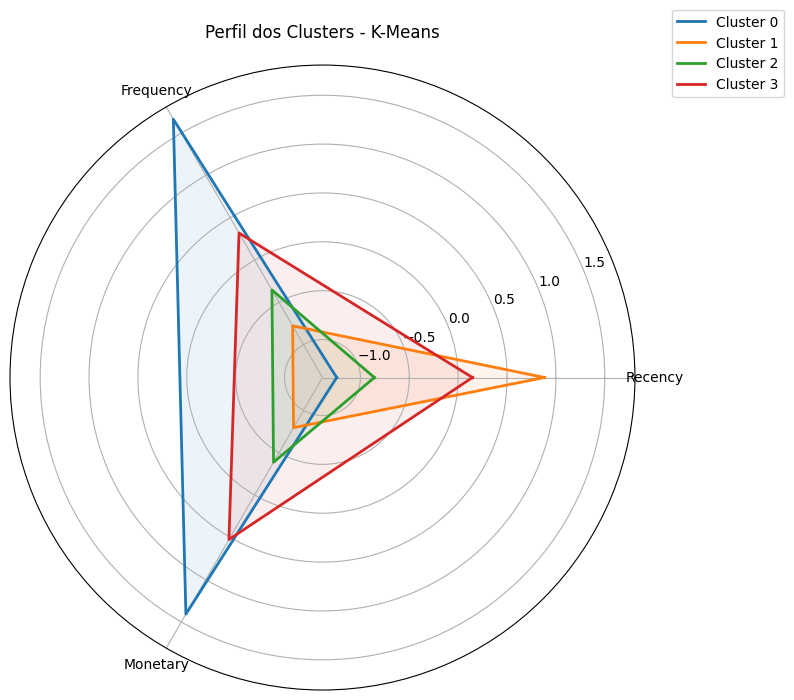

In [35]:
features_radar = ['Recency', 'Frequency', 'Monetary']

angles = np.linspace(
    0, 2 * np.pi, len(features_radar), endpoint=False
).tolist()

angles += angles[:1]

fig, ax = plt.subplots(
    figsize=(8, 8),
    subplot_kw=dict(polar=True)
)

for cluster in cluster_radar.index:
    values = cluster_radar.loc[cluster, features_radar].tolist()
    values += values[:1]

    ax.plot(
        angles,
        values,
        linewidth=2,
        label=f'Cluster {cluster}'
    )
    ax.fill(angles, values, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(features_radar)

ax.set_title(
    'Perfil dos Clusters - K-Means',
    pad=20
)

ax.legend(
    loc='upper right',
    bbox_to_anchor=(1.25, 1.1)
)

plt.tight_layout()
plt.show()

### Perfil dos clusters

Para facilitar a comparação entre os segmentos, as variáveis RFM foram representadas em escala padronizada (z-score). Valores próximos de zero representam comportamentos próximos à média da base, enquanto valores positivos ou negativos indicam desvios acima ou abaixo da média.

A variável Recency possui interpretação inversa em relação às demais: valores menores representam clientes que realizaram compras mais recentemente. Já valores maiores de Frequency e Monetary representam maior frequência de compras e maior valor financeiro, respectivamente.

In [36]:
stability_results = []

for seed in [10, 20, 30, 40, 50]:
    start_time = time.time()

    model = KMeans(
        n_clusters=4,
        random_state=seed,
        n_init=10
    )

    labels = model.fit_predict(rfm_scaled)

    elapsed = time.time() - start_time

    stability_results.append({
        'Random State': seed,
        'Inertia': model.inertia_,
        'Silhouette': silhouette_score(rfm_scaled, labels),
        'Davies-Bouldin': davies_bouldin_score(rfm_scaled, labels),
        'Tempo (s)': elapsed
    })

stability_results = pd.DataFrame(stability_results)

stability_results.round(4)

,Random State,Inertia,Silhouette,Davies-Bouldin,Tempo (s)
0,10,3938.8747,0.3352,1.0158,0.1056
1,20,3938.6434,0.3355,1.0141,0.1972
2,30,3938.6133,0.3359,1.0144,0.2057
3,40,3938.6048,0.3359,1.0127,0.1855
4,50,3938.9615,0.3372,1.0126,0.2345


### Análise de estabilidade do K-Means

Para avaliar a estabilidade do algoritmo, o K-Means com quatro clusters foi executado utilizando diferentes valores de `random_state`. Os resultados apresentaram variações muito pequenas na Inertia, no Silhouette Score e no índice Davies-Bouldin.

A Inertia permaneceu aproximadamente entre 3938,6 e 3939,0, enquanto o Silhouette Score variou entre 0,3352 e 0,3372. O índice Davies-Bouldin apresentou valores entre 1,0126 e 1,0158. Esses resultados indicam que a solução encontrada é pouco sensível à inicialização utilizada.

In [37]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
import time

linkages = ['ward', 'complete', 'average']

hierarchical_results = []

for linkage in linkages:

    start_time = time.time()

    model = AgglomerativeClustering(
        n_clusters=4,
        linkage=linkage
    )

    labels = model.fit_predict(rfm_scaled)

    elapsed = time.time() - start_time

    hierarchical_results.append({
        'Linkage': linkage,
        'Silhouette': silhouette_score(rfm_scaled, labels),
        'Davies-Bouldin': davies_bouldin_score(rfm_scaled, labels),
        'Calinski-Harabasz': calinski_harabasz_score(rfm_scaled, labels),
        'Tempo (s)': elapsed
    })

hierarchical_results = pd.DataFrame(hierarchical_results)

hierarchical_results.round(4)

,Linkage,Silhouette,Davies-Bouldin,Calinski-Harabasz,Tempo (s)
0,ward,0.2800,1.0992,2739.5701,1.3665
1,complete,0.3755,0.8382,1614.4427,1.1459
2,average,0.4316,0.5053,134.5179,1.0896


In [38]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

linkage_matrix = linkage(
    rfm_scaled,
    method='average',
    metric='euclidean'
)

print("Matriz de linkage criada com sucesso.")
print("Dimensões:", linkage_matrix.shape)

Matriz de linkage criada com sucesso.
Dimensões: (4337, 4)


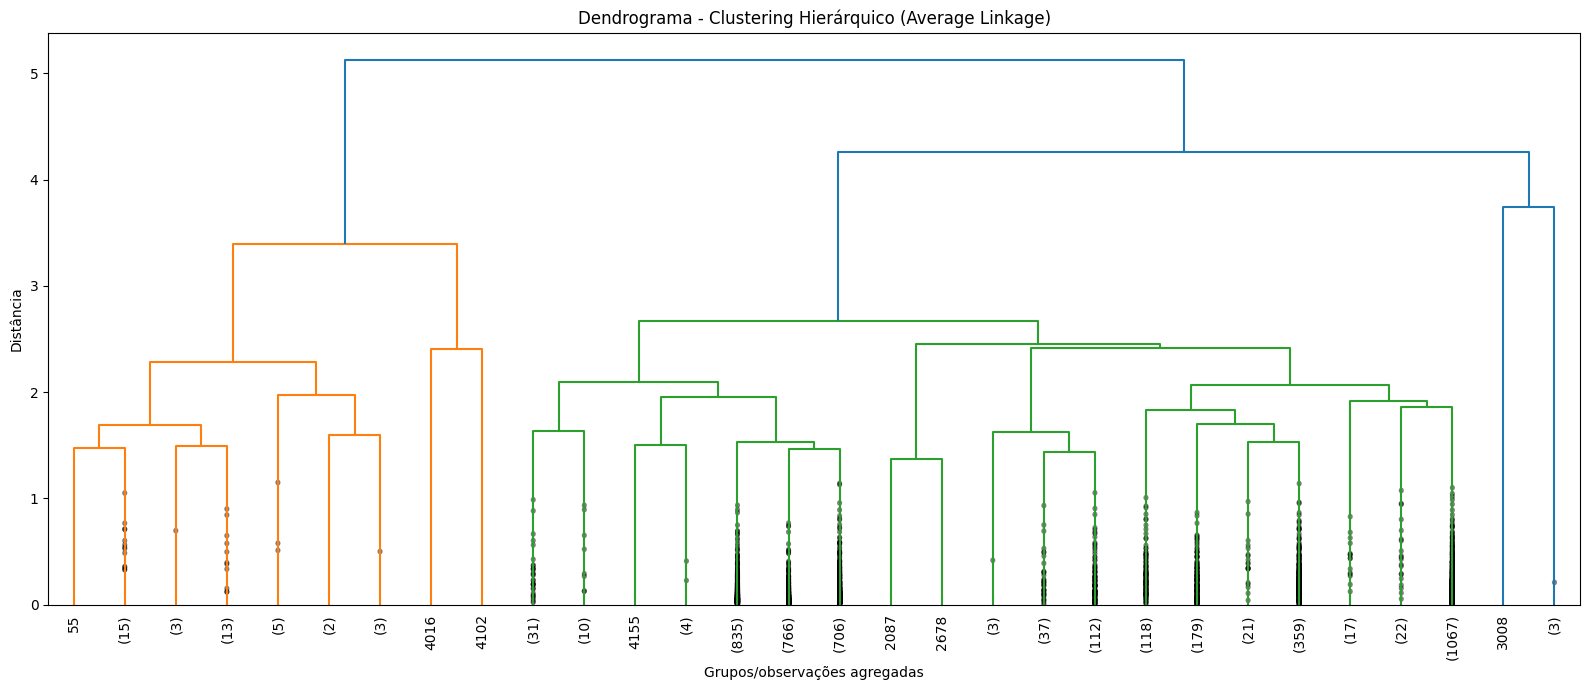

In [39]:
plt.figure(figsize=(16, 7))

dendrogram(
    linkage_matrix,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True
)

plt.title('Dendrograma - Clustering Hierárquico (Average Linkage)')
plt.xlabel('Grupos/observações agregadas')
plt.ylabel('Distância')
plt.tight_layout()
plt.show()

### Interpretação do dendrograma

O dendrograma obtido pelo método de agrupamento hierárquico com `average linkage` apresenta diferentes níveis de agregação dos clientes. Observam-se fusões em distâncias menores entre grupos mais semelhantes e aumentos mais acentuados na distância nas etapas finais de agregação. Esses saltos indicam níveis nos quais grupos relativamente distintos são combinados, fornecendo referência para a definição do número de clusters.

A visualização foi truncada para facilitar a interpretação, devido ao grande número de clientes da base.

In [40]:
hierarchical_final = AgglomerativeClustering(
    n_clusters=4,
    linkage='average'
)

hierarchical_labels = hierarchical_final.fit_predict(rfm_scaled)

print("Clusters encontrados:")
print(pd.Series(hierarchical_labels).value_counts().sort_index())

Clusters encontrados:
0      44
1       3
2    4290
3       1
Name: count, dtype: int64


In [41]:
hierarchical_silhouette = silhouette_score(
    rfm_scaled,
    hierarchical_labels
)

hierarchical_db = davies_bouldin_score(
    rfm_scaled,
    hierarchical_labels
)

hierarchical_ch = calinski_harabasz_score(
    rfm_scaled,
    hierarchical_labels
)

print(f"Silhouette Score: {hierarchical_silhouette:.4f}")
print(f"Davies-Bouldin Index: {hierarchical_db:.4f}")
print(f"Calinski-Harabasz Score: {hierarchical_ch:.2f}")

Silhouette Score: 0.4316
Davies-Bouldin Index: 0.5053
Calinski-Harabasz Score: 134.52


In [42]:
linkages = ['ward', 'complete', 'average']
k_values_hier = range(2, 9)

hierarchical_comparison = []

for linkage in linkages:
    for k in k_values_hier:

        start_time = time.time()

        model = AgglomerativeClustering(
            n_clusters=k,
            linkage=linkage
        )

        labels = model.fit_predict(rfm_scaled)

        elapsed = time.time() - start_time

        cluster_counts = pd.Series(labels).value_counts()

        hierarchical_comparison.append({
            'Linkage': linkage,
            'K': k,
            'Silhouette': silhouette_score(rfm_scaled, labels),
            'Davies-Bouldin': davies_bouldin_score(rfm_scaled, labels),
            'Calinski-Harabasz': calinski_harabasz_score(rfm_scaled, labels),
            'Menor_Cluster_%': (cluster_counts.min() / len(labels)) * 100,
            'Maior_Cluster_%': (cluster_counts.max() / len(labels)) * 100,
            'Tempo (s)': elapsed
        })

hierarchical_comparison = pd.DataFrame(hierarchical_comparison)

hierarchical_comparison.round(4)

,Linkage,K,Silhouette,Davies-Bouldin,Calinski-Harabasz,Menor_Cluster_%,Maior_Cluster_%,Tempo (s)
0,ward,2,0.4040,0.9405,3168.2251,25.4726,74.5274,2.0614
1,ward,3,0.2843,1.1327,2960.2515,25.4726,39.5574,2.2049
2,ward,4,0.2800,1.0992,2739.5701,7.9069,39.5574,1.1750
3,ward,5,0.2805,1.0308,2754.9480,7.9069,34.9700,1.0968
4,ward,6,0.2660,1.1079,2606.2068,7.9069,26.3716,0.7143
5,ward,7,0.2582,1.1081,2484.4741,4.8640,26.3716,0.7115
6,ward,8,0.2515,1.1294,2386.9289,4.8640,20.7008,0.7109
7,complete,2,0.4012,0.9412,3929.7766,43.1305,56.8695,0.7799
8,complete,3,0.3760,0.8394,2392.0679,1.0834,56.8695,0.7797
9,complete,4,0.3755,0.8382,1614.4427,0.0922,56.8695,0.7697


In [43]:
hierarchical_final = AgglomerativeClustering(
    n_clusters=2,
    linkage='complete'
)

hierarchical_labels = hierarchical_final.fit_predict(rfm_scaled)

cluster_counts_hier = pd.Series(
    hierarchical_labels
).value_counts().sort_index()

print("Quantidade de clientes por cluster:")
print(cluster_counts_hier)

print("\nPercentual de clientes:")
print(
    (cluster_counts_hier / len(rfm) * 100).round(2)
)

Quantidade de clientes por cluster:
0    1871
1    2467
Name: count, dtype: int64

Percentual de clientes:
0    43.13
1    56.87
Name: count, dtype: float64


In [44]:
hierarchical_silhouette = silhouette_score(
    rfm_scaled,
    hierarchical_labels
)

hierarchical_db = davies_bouldin_score(
    rfm_scaled,
    hierarchical_labels
)

hierarchical_ch = calinski_harabasz_score(
    rfm_scaled,
    hierarchical_labels
)

print(f"Silhouette Score: {hierarchical_silhouette:.4f}")
print(f"Davies-Bouldin Index: {hierarchical_db:.4f}")
print(f"Calinski-Harabasz Score: {hierarchical_ch:.2f}")

Silhouette Score: 0.4012
Davies-Bouldin Index: 0.9412
Calinski-Harabasz Score: 3929.78


In [45]:
rfm_hier = rfm.copy()

rfm_hier['Hierarchical_Cluster'] = hierarchical_labels

hierarchical_profile = rfm_hier.groupby(
    'Hierarchical_Cluster'
)[['Recency', 'Frequency', 'Monetary']].agg(
    ['count', 'mean', 'median']
).round(2)

hierarchical_profile

Recency                Frequency              Monetary  \
                       count    mean median     count  mean median    count   
Hierarchical_Cluster                                                          
0                       1871   35.77   20.0      1871  7.86    5.0     1871   
1                       2467  135.59  100.0      2467  1.55    1.0     2467   

                                        
                         mean   median  
Hierarchical_Cluster                    
0                     4182.87  1880.22  
1                      430.10   333.08

In [46]:
hierarchical_business = rfm_hier.groupby(
    'Hierarchical_Cluster'
).agg(
    Clientes=('CustomerID', 'count'),
    Recency_Media=('Recency', 'mean'),
    Frequency_Media=('Frequency', 'mean'),
    Monetary_Medio=('Monetary', 'mean'),
    Receita_Total=('Monetary', 'sum')
).round(2)

hierarchical_business['% da Receita'] = (
    hierarchical_business['Receita_Total']
    / hierarchical_business['Receita_Total'].sum()
    * 100
).round(2)

hierarchical_business['% dos Clientes'] = (
    hierarchical_business['Clientes']
    / len(rfm_hier)
    * 100
).round(2)

hierarchical_business

,Clientes,Recency_Media,Frequency_Media,Monetary_Medio,Receita_Total,% da Receita,% dos Clientes
Hierarchical_Cluster,,,,,,,
0,1871,35.77,7.86,4182.87,7826147.76,88.06,43.13
1,2467,135.59,1.55,430.10,1061061.13,11.94,56.87


### Perfil dos clusters - Clustering Hierárquico

A solução hierárquica com Complete Linkage e dois clusters produziu uma segmentação com distribuição relativamente equilibrada entre os clientes. O Cluster 0 representa 43,13% da base, mas concentra 88,06% da receita total. Esses clientes apresentam menor Recency média (35,77 dias), maior Frequency média (7,86 compras) e Monetary médio de £4.182,87, caracterizando um grupo de maior engajamento e valor financeiro.

O Cluster 1 representa 56,87% dos clientes e responde por 11,94% da receita. Esse grupo apresenta Recency média de 135,59 dias, Frequency média de 1,55 compra e Monetary médio de £430,10, indicando menor atividade e menor contribuição financeira.

Os resultados demonstram que a segmentação hierárquica identifica uma diferença relevante entre clientes de maior valor e clientes de menor engajamento.

In [48]:
linkage_matrix_complete = linkage(
    rfm_scaled,
    method='complete',
    metric='euclidean'
)

plt.figure(figsize=(16, 7))

dendrogram(
    linkage_matrix_complete,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True
)

plt.title('Dendrograma - Clustering Hierárquico (Complete Linkage)')
plt.xlabel('Grupos/observações agregadas')
plt.ylabel('Distância')

plt.tight_layout()
plt.show()

TypeError: 'str' object is not callable

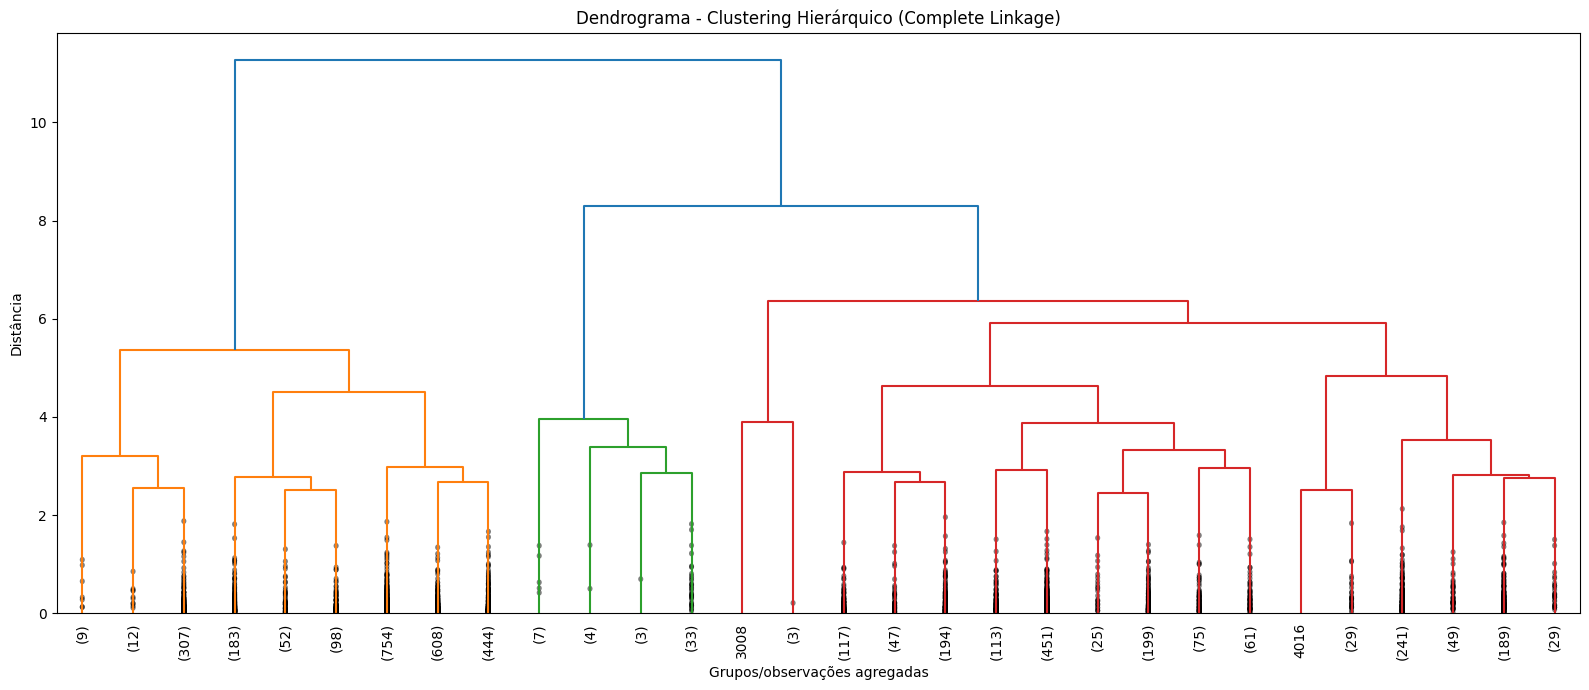

In [49]:
from scipy.cluster.hierarchy import linkage as scipy_linkage, dendrogram

linkage_matrix_complete = scipy_linkage(
    rfm_scaled,
    method='complete',
    metric='euclidean'
)

plt.figure(figsize=(16, 7))

dendrogram(
    linkage_matrix_complete,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True
)

plt.title('Dendrograma - Clustering Hierárquico (Complete Linkage)')
plt.xlabel('Grupos/observações agregadas')
plt.ylabel('Distância')

plt.tight_layout()
plt.show()

### Interpretação do dendrograma - Complete Linkage

O dendrograma obtido com o método Complete Linkage apresenta a estrutura hierárquica dos clientes após a aplicação do agrupamento aglomerativo. Observa-se um aumento significativo nas distâncias das fusões nas etapas superiores da árvore, indicando a combinação de grupos progressivamente mais distintos.

Considerando a análise das métricas de validação e do balanceamento dos grupos, foi adotado um corte correspondente a dois clusters. Essa configuração produziu grupos relativamente equilibrados, com 43,13% e 56,87% dos clientes, evitando a formação de clusters extremamente pequenos observada em algumas outras configurações.

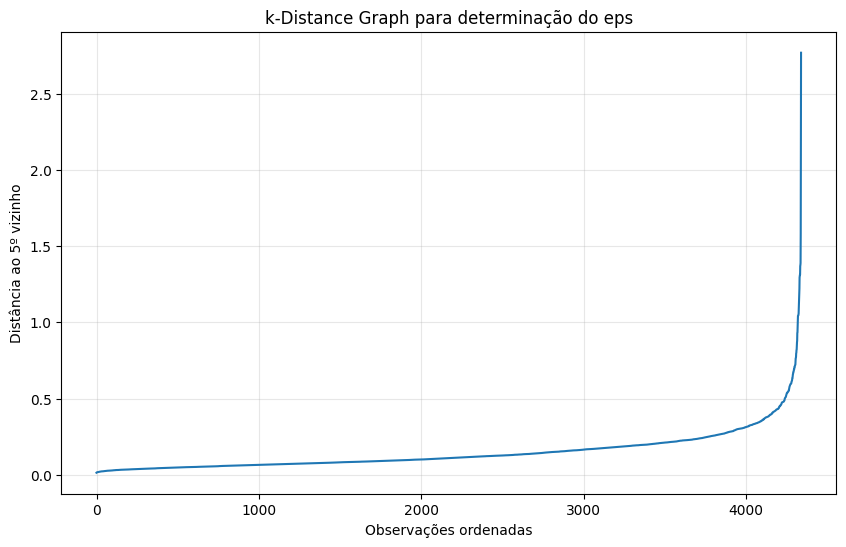

In [50]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# Número de vizinhos utilizado para estimar o eps
k = 5

neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(rfm_scaled)

distances, indices = neighbors_fit.kneighbors(rfm_scaled)

# Distância até o k-ésimo vizinho
k_distances = np.sort(distances[:, k-1])

plt.figure(figsize=(10, 6))

plt.plot(k_distances)

plt.title('k-Distance Graph para determinação do eps')
plt.xlabel('Observações ordenadas')
plt.ylabel(f'Distância ao {k}º vizinho')

plt.grid(True, alpha=0.3)
plt.show()

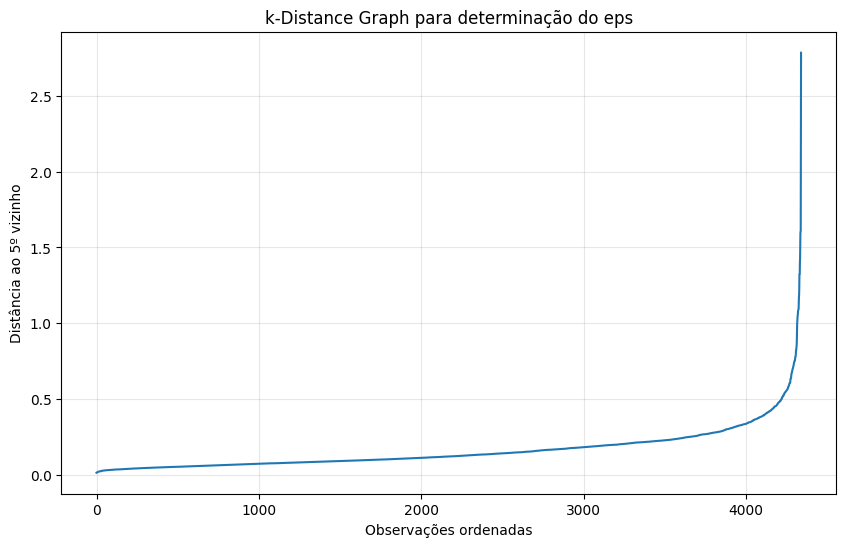

In [52]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

k = 5

neighbors = NearestNeighbors(n_neighbors=k + 1)
neighbors_fit = neighbors.fit(rfm_scaled)

distances, indices = neighbors_fit.kneighbors(rfm_scaled)

# Ignora o próprio ponto (primeira coluna)
k_distances = np.sort(distances[:, k])

plt.figure(figsize=(10, 6))

plt.plot(k_distances)

plt.title('k-Distance Graph para determinação do eps')
plt.xlabel('Observações ordenadas')
plt.ylabel(f'Distância ao {k}º vizinho')

plt.grid(True, alpha=0.3)
plt.show()

In [53]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
import pandas as pd
import time

eps_values = [0.50, 0.55, 0.60, 0.65]

dbscan_results = []

for eps in eps_values:

    start_time = time.time()

    dbscan = DBSCAN(
        eps=eps,
        min_samples=5,
        metric='euclidean'
    )

    labels = dbscan.fit_predict(rfm_scaled)

    elapsed = time.time() - start_time

    # Número de pontos considerados ruído
    noise_count = (labels == -1).sum()
    noise_pct = noise_count / len(labels) * 100

    # Número de clusters, excluindo o ruído
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    # Métricas calculadas somente para pontos que não são ruído
    mask = labels != -1

    if n_clusters >= 2 and mask.sum() > 1:
        sil = silhouette_score(
            rfm_scaled[mask],
            labels[mask]
        )

        db = davies_bouldin_score(
            rfm_scaled[mask],
            labels[mask]
        )

        ch = calinski_harabasz_score(
            rfm_scaled[mask],
            labels[mask]
        )
    else:
        sil = np.nan
        db = np.nan
        ch = np.nan

    dbscan_results.append({
        'eps': eps,
        'Clusters': n_clusters,
        'Ruído': noise_count,
        '% Ruído': noise_pct,
        'Silhouette': sil,
        'Davies-Bouldin': db,
        'Calinski-Harabasz': ch,
        'Tempo (s)': elapsed
    })

dbscan_results = pd.DataFrame(dbscan_results)

dbscan_results.round(4)

,eps,Clusters,Ruído,% Ruído,Silhouette,Davies-Bouldin,Calinski-Harabasz,Tempo (s)
0,0.50,2,62,1.4292,0.2930,1.0636,2390.1964,0.1236
1,0.55,2,50,1.1526,0.2927,1.0629,2393.7107,0.2524
2,0.60,2,33,0.7607,0.5670,0.3480,50.3408,0.3111
3,0.65,2,28,0.6455,0.5618,0.3740,58.4550,0.2902


### Determinação do parâmetro eps

O parâmetro `eps` do DBSCAN foi inicialmente delimitado por meio do k-distance graph, utilizando a distância até o quinto vizinho mais próximo. O gráfico indicou uma mudança mais acentuada na inclinação da curva aproximadamente na faixa entre 0,5 e 0,6, motivando o teste de valores próximos a essa região.

Foram avaliados os valores de `eps` = 0,50, 0,55, 0,60 e 0,65, mantendo `min_samples = 5`. Todas as configurações produziram dois clusters, porém apresentaram diferenças nas métricas de validação e na quantidade de observações classificadas como ruído.

Entre os valores avaliados, `eps = 0,65` apresentou o maior Silhouette Score (0,3740), o menor índice Davies-Bouldin (0,5618) e o maior índice Calinski-Harabasz entre as configurações de 0,60 e 0,65, além de classificar apenas 0,65% das observações como ruído. Dessa forma, esse valor foi selecionado para o modelo DBSCAN final.

In [54]:
dbscan_final = DBSCAN(
    eps=0.65,
    min_samples=5,
    metric='euclidean'
)

dbscan_labels = dbscan_final.fit_predict(rfm_scaled)

# Distribuição dos clusters
dbscan_counts = pd.Series(
    dbscan_labels
).value_counts().sort_index()

print("Quantidade de observações por cluster:")
print(dbscan_counts)

print("\nPercentual de observações por cluster:")
print(
    (dbscan_counts / len(rfm) * 100).round(2)
)

Quantidade de observações por cluster:
-1      28
 0    4304
 1       6
Name: count, dtype: int64

Percentual de observações por cluster:
-1     0.65
 0    99.22
 1     0.14
Name: count, dtype: float64


In [55]:
eps_values = [0.70, 0.75, 0.80, 0.90, 1.00]

dbscan_results_2 = []

for eps in eps_values:

    start_time = time.time()

    dbscan = DBSCAN(
        eps=eps,
        min_samples=5,
        metric='euclidean'
    )

    labels = dbscan.fit_predict(rfm_scaled)

    elapsed = time.time() - start_time

    noise_count = (labels == -1).sum()
    noise_pct = noise_count / len(labels) * 100

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    mask = labels != -1

    if n_clusters >= 2 and mask.sum() > 1:
        sil = silhouette_score(
            rfm_scaled[mask],
            labels[mask]
        )

        db = davies_bouldin_score(
            rfm_scaled[mask],
            labels[mask]
        )

        ch = calinski_harabasz_score(
            rfm_scaled[mask],
            labels[mask]
        )
    else:
        sil = np.nan
        db = np.nan
        ch = np.nan

    dbscan_results_2.append({
        'eps': eps,
        'Clusters': n_clusters,
        'Ruído': noise_count,
        '% Ruído': noise_pct,
        'Silhouette': sil,
        'Davies-Bouldin': db,
        'Calinski-Harabasz': ch,
        'Tempo (s)': elapsed
    })

dbscan_results_2 = pd.DataFrame(dbscan_results_2)

dbscan_results_2.round(4)

,eps,Clusters,Ruído,% Ruído,Silhouette,Davies-Bouldin,Calinski-Harabasz,Tempo (s)
0,0.70,2,26,0.5994,0.564,0.3496,49.5872,0.1905
1,0.75,1,22,0.5071,NaN,NaN,NaN,0.2203
2,0.80,1,21,0.4841,NaN,NaN,NaN,0.4029
3,0.90,1,13,0.2997,NaN,NaN,NaN,0.3355
4,1.00,1,10,0.2305,NaN,NaN,NaN,0.5810


In [56]:
dbscan_070 = DBSCAN(
    eps=0.70,
    min_samples=5,
    metric='euclidean'
)

labels_070 = dbscan_070.fit_predict(rfm_scaled)

dbscan_counts_070 = pd.Series(
    labels_070
).value_counts().sort_index()

print("Quantidade de observações por cluster:")
print(dbscan_counts_070)

print("\nPercentual de observações por cluster:")
print(
    (dbscan_counts_070 / len(rfm) * 100).round(2)
)

Quantidade de observações por cluster:
-1      26
 0    4307
 1       5
Name: count, dtype: int64

Percentual de observações por cluster:
-1     0.60
 0    99.29
 1     0.12
Name: count, dtype: float64


In [57]:
from sklearn.mixture import GaussianMixture
import time

n_components_range = range(2, 9)

gmm_results = []

for n in n_components_range:

    start_time = time.time()

    gmm = GaussianMixture(
        n_components=n,
        covariance_type='full',
        random_state=42,
        n_init=10
    )

    gmm.fit(rfm_scaled)

    elapsed = time.time() - start_time

    labels = gmm.predict(rfm_scaled)

    gmm_results.append({
        'Componentes': n,
        'BIC': gmm.bic(rfm_scaled),
        'AIC': gmm.aic(rfm_scaled),
        'Silhouette': silhouette_score(
            rfm_scaled,
            labels
        ),
        'Davies-Bouldin': davies_bouldin_score(
            rfm_scaled,
            labels
        ),
        'Calinski-Harabasz': calinski_harabasz_score(
            rfm_scaled,
            labels
        ),
        'Tempo (s)': elapsed
    })

gmm_results = pd.DataFrame(gmm_results)

gmm_results.round(4)

,Componentes,BIC,AIC,Silhouette,Davies-Bouldin,Calinski-Harabasz,Tempo (s)
0,2,13456.2219,13335.0936,0.2855,1.0670,2288.4854,3.8843
1,3,12624.4115,12439.5316,0.2521,1.2468,2749.9039,3.1819
2,4,3841.9100,3593.2784,0.1728,1.7237,2146.5625,2.1451
3,5,3535.5117,3223.1284,0.1542,1.7794,1899.3857,1.1869
4,6,-1353.8662,-1730.0011,0.1225,2.1805,1496.6556,1.7622
5,7,-5048.1477,-5488.0344,0.1071,2.5323,1322.3812,3.8375
6,8,-5579.1888,-6082.8272,0.1236,2.4063,1355.4546,3.1932


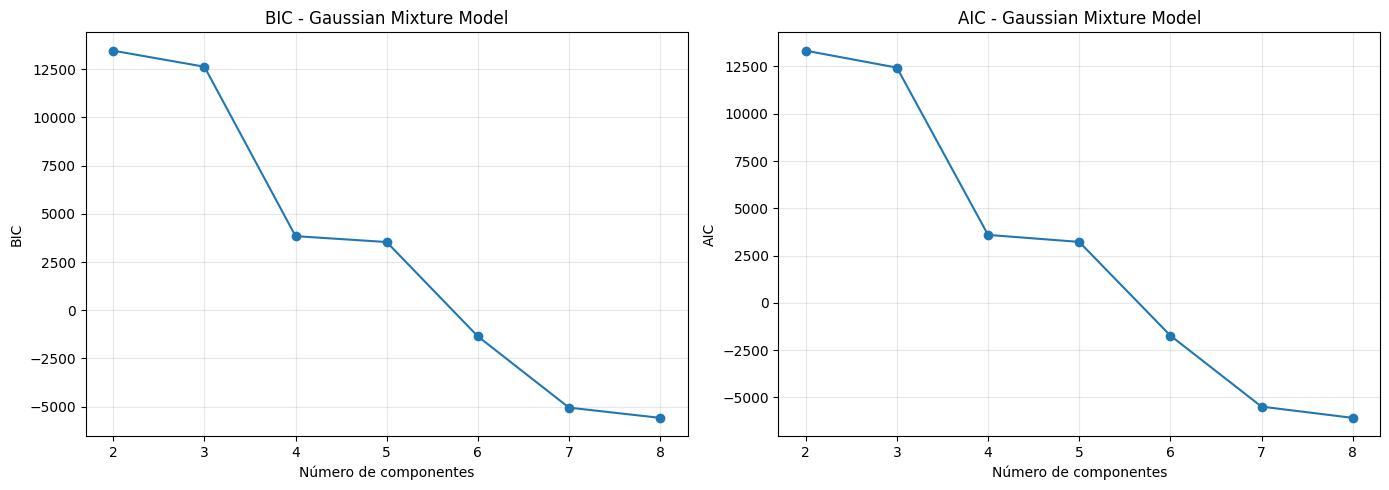

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BIC
axes[0].plot(
    gmm_results['Componentes'],
    gmm_results['BIC'],
    marker='o'
)

axes[0].set_title('BIC - Gaussian Mixture Model')
axes[0].set_xlabel('Número de componentes')
axes[0].set_ylabel('BIC')
axes[0].set_xticks(gmm_results['Componentes'])
axes[0].grid(True, alpha=0.3)

# AIC
axes[1].plot(
    gmm_results['Componentes'],
    gmm_results['AIC'],
    marker='o'
)

axes[1].set_title('AIC - Gaussian Mixture Model')
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('AIC')
axes[1].set_xticks(gmm_results['Componentes'])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [59]:
# Comparação dos tamanhos dos clusters para diferentes números de componentes

for n in [2, 4, 8]:
    gmm_temp = GaussianMixture(
        n_components=n,
        covariance_type='full',
        random_state=42,
        n_init=10
    )

    labels_temp = gmm_temp.fit_predict(rfm_scaled)

    counts = pd.Series(labels_temp).value_counts().sort_index()
    percentages = (counts / len(labels_temp) * 100).round(2)

    print(f"\nGMM com {n} componentes:")
    print(pd.DataFrame({
        'Clientes': counts,
        '%': percentages
    }))


GMM com 2 componentes:
   Clientes      %
0      1493  34.42
1      2845  65.58

GMM com 4 componentes:
   Clientes      %
0      1073  24.73
1       937  21.60
2       835  19.25
3      1493  34.42

GMM com 8 componentes:
   Clientes      %
0       634  14.62
1       439  10.12
2        68   1.57
3       506  11.66
4       611  14.08
5       834  19.23
6       388   8.94
7       858  19.78


In [60]:
# GMM final com 4 componentes

gmm_final = GaussianMixture(
    n_components=4,
    covariance_type='full',
    random_state=42,
    n_init=10
)

gmm_labels = gmm_final.fit_predict(rfm_scaled)

# Probabilidade de cada cliente pertencer a cada cluster
gmm_probabilities = gmm_final.predict_proba(rfm_scaled)

# Maior probabilidade de pertencimento de cada cliente
gmm_confidence = gmm_probabilities.max(axis=1)

# Adiciona os resultados ao dataframe RFM
rfm_gmm = rfm.copy()
rfm_gmm['Cluster'] = gmm_labels
rfm_gmm['GMM_Confidence'] = gmm_confidence

# Métricas finais
print("BIC:", round(gmm_final.bic(rfm_scaled), 4))
print("AIC:", round(gmm_final.aic(rfm_scaled), 4))
print("Silhouette:", round(silhouette_score(rfm_scaled, gmm_labels), 4))
print("Davies-Bouldin:", round(davies_bouldin_score(rfm_scaled, gmm_labels), 4))
print("Calinski-Harabasz:", round(calinski_harabasz_score(rfm_scaled, gmm_labels), 4))

BIC: 3841.91
AIC: 3593.2784
Silhouette: 0.1728
Davies-Bouldin: 1.7237
Calinski-Harabasz: 2146.5625


In [61]:
# Perfil dos clusters do GMM

gmm_profile = rfm_gmm.groupby('Cluster').agg(
    Clientes=('CustomerID', 'count'),
    Recency_Media=('Recency', 'mean'),
    Frequency_Media=('Frequency', 'mean'),
    Monetary_Media=('Monetary', 'mean'),
    Recency_Mediana=('Recency', 'median'),
    Frequency_Mediana=('Frequency', 'median'),
    Monetary_Mediana=('Monetary', 'median'),
    Confianca_Media=('GMM_Confidence', 'mean')
).round(2)

gmm_profile

,Clientes,Recency_Media,Frequency_Media,Monetary_Media,Recency_Mediana,Frequency_Mediana,Monetary_Mediana,Confianca_Media
Cluster,,,,,,,,
0,1073,67.52,3.92,1609.68,46.0,4.0,1121.59,0.84
1,937,17.70,11.91,6199.11,9.0,8.0,2755.63,0.90
2,835,93.97,2.00,883.19,61.0,2.0,547.06,1.00
3,1493,156.68,1.00,411.25,132.0,1.0,255.91,1.00


In [62]:
# Impacto financeiro dos clusters GMM

gmm_business = rfm_gmm.groupby('Cluster').agg(
    Clientes=('CustomerID', 'count'),
    Recencia_Media=('Recency', 'mean'),
    Frequencia_Media=('Frequency', 'mean'),
    Monetary_Medio=('Monetary', 'mean'),
    Receita_Total=('Monetary', 'sum')
).reset_index()

# Percentual de clientes
gmm_business['% Clientes'] = (
    gmm_business['Clientes'] / gmm_business['Clientes'].sum() * 100
)

# Participação na receita
gmm_business['% Receita'] = (
    gmm_business['Receita_Total'] / gmm_business['Receita_Total'].sum() * 100
)

gmm_business = gmm_business.round(2)

gmm_business

,Cluster,Clientes,Recencia_Media,Frequencia_Media,Monetary_Medio,Receita_Total,% Clientes,% Receita
0,0,1073,67.52,3.92,1609.68,1727187.85,24.73,19.43
1,1,937,17.70,11.91,6199.11,5808567.73,21.60,65.36
2,2,835,93.97,2.00,883.19,737463.75,19.25,8.30
3,3,1493,156.68,1.00,411.25,613989.56,34.42,6.91


In [63]:
# Comparação final dos algoritmos de clustering

comparison = pd.DataFrame({
    'Algoritmo': [
        'K-Means',
        'Hierarchical - Complete',
        'GMM'
    ],
    'Clusters': [
        4,
        2,
        4
    ],
    'Silhouette': [
        0.3375,
        0.4012,
        0.1728
    ],
    'Davies-Bouldin': [
        1.0086,
        0.9412,
        1.7237
    ],
    'Calinski-Harabasz': [
        3328.34,
        3929.78,
        2146.56
    ],
    'Tempo (s)': [
        0.1102,
        1.1459,
        2.1451
    ]
})

comparison.round(4)

,Algoritmo,Clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz,Tempo (s)
0,K-Means,4,0.3375,1.0086,3328.34,0.1102
1,Hierarchical - Complete,2,0.4012,0.9412,3929.78,1.1459
2,GMM,4,0.1728,1.7237,2146.56,2.1451


Comparação dos algoritmos: Os resultados mostram diferenças entre os métodos de agrupamento. O K-Means apresentou Silhouette de 0,3375 e Davies-Bouldin de 1,0086, além do menor tempo de execução (0,1102 s). O agrupamento hierárquico com Complete Linkage apresentou a maior Silhouette (0,4012), o menor Davies-Bouldin (0,9412) e o maior índice de Calinski-Harabasz (3929,78) entre os três modelos, embora tenha utilizado um tempo maior de execução. O GMM apresentou Silhouette de 0,1728 e Davies-Bouldin de 1,7237, indicando menor separação segundo essas métricas. Entretanto, o GMM possui como diferencial a possibilidade de representar a probabilidade de pertencimento dos clientes aos segmentos. Portanto, a comparação deve considerar tanto as métricas quantitativas quanto a estrutura dos grupos e sua interpretabilidade para o problema de segmentação de clientes.

In [64]:
from sklearn.decomposition import PCA

# PCA com todos os componentes
pca_full = PCA()
pca_full.fit(rfm_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

pca_variance = pd.DataFrame({
    'Componente': range(1, len(explained_variance) + 1),
    'Variância Individual': explained_variance,
    'Variância Acumulada': cumulative_variance
})

pca_variance.round(4)

,Componente,Variância Individual,Variância Acumulada
0,1,0.7508,0.7508
1,2,0.1879,0.9387
2,3,0.0613,1.0000


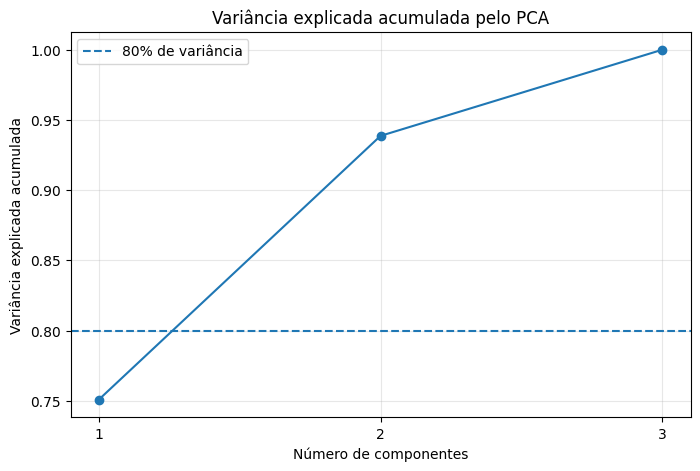

In [65]:
plt.figure(figsize=(8, 5))

plt.plot(
    pca_variance['Componente'],
    pca_variance['Variância Acumulada'],
    marker='o'
)

plt.axhline(
    y=0.80,
    linestyle='--',
    label='80% de variância'
)

plt.xlabel('Número de componentes')
plt.ylabel('Variância explicada acumulada')
plt.title('Variância explicada acumulada pelo PCA')
plt.xticks(pca_variance['Componente'])
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [66]:
# PCA com 2 componentes
pca_2d = PCA(n_components=2)

rfm_pca = pca_2d.fit_transform(rfm_scaled)

# Criar dataframe com as coordenadas
pca_df = pd.DataFrame(
    rfm_pca,
    columns=['PC1', 'PC2'],
    index=rfm.index
)

# Adicionar cluster do K-Means
pca_df['Cluster'] = kmeans_labels

pca_df.head()

,PC1,PC2,Cluster
0,0.873338,2.691611,3
1,2.551874,-0.802858,0
2,0.477339,0.747867,3
3,0.147609,-0.457066,2
4,-1.686255,0.679035,1


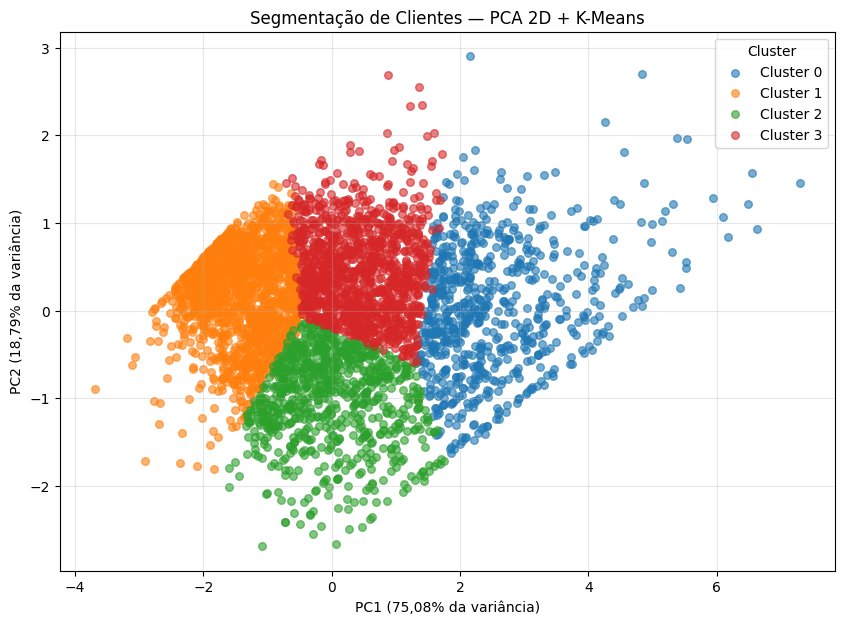

In [67]:
plt.figure(figsize=(10, 7))

for cluster in sorted(pca_df['Cluster'].unique()):
    cluster_data = pca_df[pca_df['Cluster'] == cluster]

    plt.scatter(
        cluster_data['PC1'],
        cluster_data['PC2'],
        label=f'Cluster {cluster}',
        alpha=0.6,
        s=30
    )

plt.xlabel('PC1 (75,08% da variância)')
plt.ylabel('PC2 (18,79% da variância)')
plt.title('Segmentação de Clientes — PCA 2D + K-Means')
plt.legend(title='Cluster')
plt.grid(True, alpha=0.3)

plt.show()

In [68]:
# Cargas (loadings) das variáveis nos componentes principais

loadings = pd.DataFrame(
    pca_2d.components_.T,
    columns=['PC1', 'PC2'],
    index=features
)

loadings.round(4)

,PC1,PC2
Recency,-0.5119,0.8495
Frequency,0.6180,0.2613
Monetary,0.5966,0.4583


Interpretação dos componentes principais: O primeiro componente principal (PC1), responsável por 75,08% da variância, apresenta maiores cargas positivas para Frequency (0,6180) e Monetary (0,5966), enquanto Recency apresenta carga negativa (-0,5119). Dessa forma, o PC1 pode ser interpretado como um eixo associado ao valor e ao engajamento dos clientes, relacionando maior frequência e valor monetário a menor recência. O segundo componente (PC2), responsável por 18,79% da variância, apresenta forte predominância da variável Recency (0,8495), representando principalmente diferenças relacionadas à recência das compras. Juntos, os dois componentes explicam 93,87% da variância dos dados.

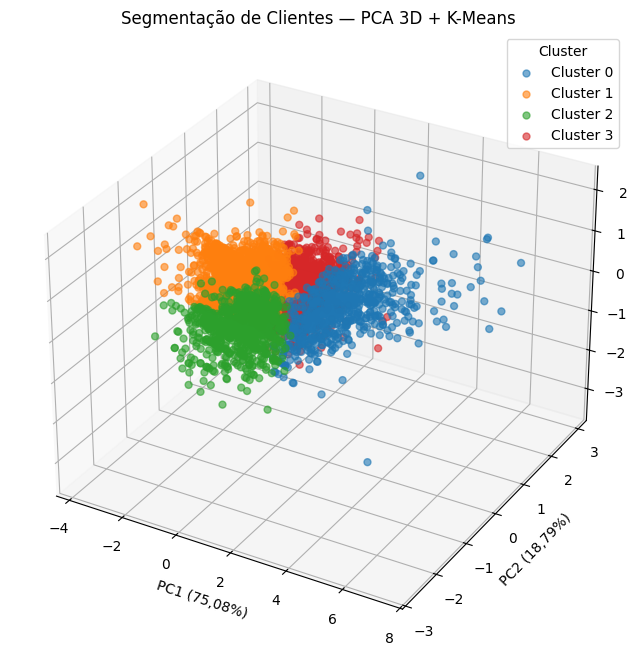

In [69]:
from mpl_toolkits.mplot3d import Axes3D

# PCA com 3 componentes
pca_3d = PCA(n_components=3)
rfm_pca_3d = pca_3d.fit_transform(rfm_scaled)

pca_3d_df = pd.DataFrame(
    rfm_pca_3d,
    columns=['PC1', 'PC2', 'PC3'],
    index=rfm.index
)

pca_3d_df['Cluster'] = kmeans_labels

# Gráfico 3D
fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection='3d')

for cluster in sorted(pca_3d_df['Cluster'].unique()):
    cluster_data = pca_3d_df[pca_3d_df['Cluster'] == cluster]

    ax.scatter(
        cluster_data['PC1'],
        cluster_data['PC2'],
        cluster_data['PC3'],
        label=f'Cluster {cluster}',
        alpha=0.6,
        s=25
    )

ax.set_xlabel('PC1 (75,08%)')
ax.set_ylabel('PC2 (18,79%)')
ax.set_zlabel('PC3 (6,13%)')
ax.set_title('Segmentação de Clientes — PCA 3D + K-Means')
ax.legend(title='Cluster')

plt.show()

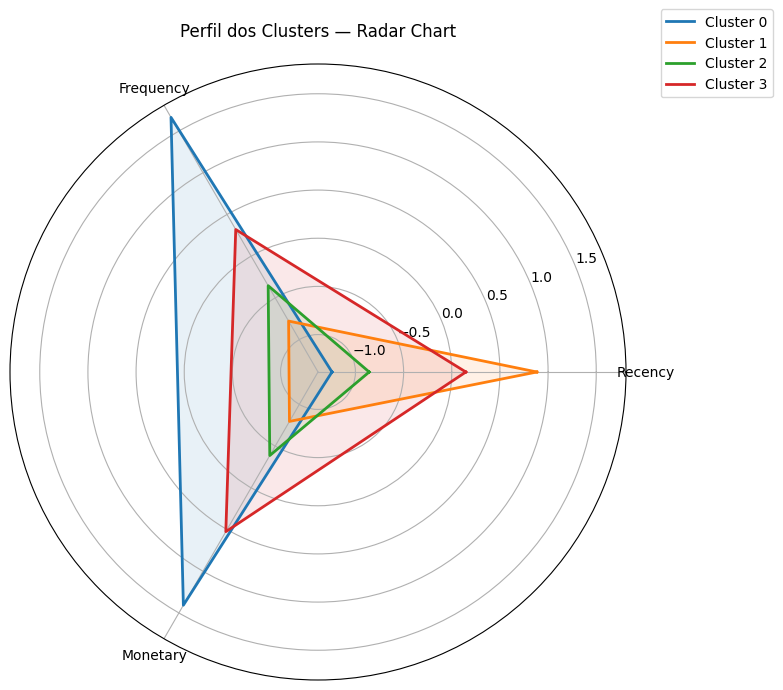

In [70]:
import numpy as np
import matplotlib.pyplot as plt

# Média das variáveis padronizadas por cluster
radar_data = rfm_scaled.copy()
radar_data['Cluster'] = kmeans_labels

radar_profile = radar_data.groupby('Cluster')[features].mean()

# Número de variáveis
num_vars = len(features)

# Ângulos do radar
angles = np.linspace(
    0,
    2 * np.pi,
    num_vars,
    endpoint=False
).tolist()

# Fechar o círculo
angles += angles[:1]

fig, ax = plt.subplots(
    figsize=(8, 8),
    subplot_kw=dict(polar=True)
)

for cluster in radar_profile.index:
    values = radar_profile.loc[cluster].tolist()
    values += values[:1]

    ax.plot(
        angles,
        values,
        linewidth=2,
        label=f'Cluster {cluster}'
    )

    ax.fill(
        angles,
        values,
        alpha=0.10
    )

ax.set_xticks(angles[:-1])
ax.set_xticklabels(features)

ax.set_title(
    'Perfil dos Clusters — Radar Chart',
    pad=20
)

ax.legend(
    loc='upper right',
    bbox_to_anchor=(1.25, 1.10)
)

plt.show()

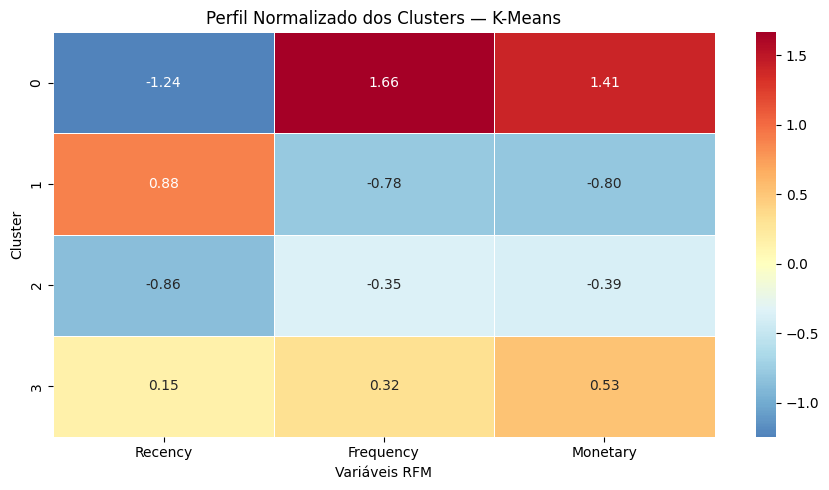

In [71]:
# Heatmap do perfil médio dos clusters

heatmap_data = rfm_scaled.copy()
heatmap_data['Cluster'] = kmeans_labels

heatmap_profile = heatmap_data.groupby('Cluster')[features].mean()

plt.figure(figsize=(9, 5))

sns.heatmap(
    heatmap_profile,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r',
    center=0,
    linewidths=0.5
)

plt.title('Perfil Normalizado dos Clusters — K-Means')
plt.xlabel('Variáveis RFM')
plt.ylabel('Cluster')

plt.tight_layout()
plt.show()

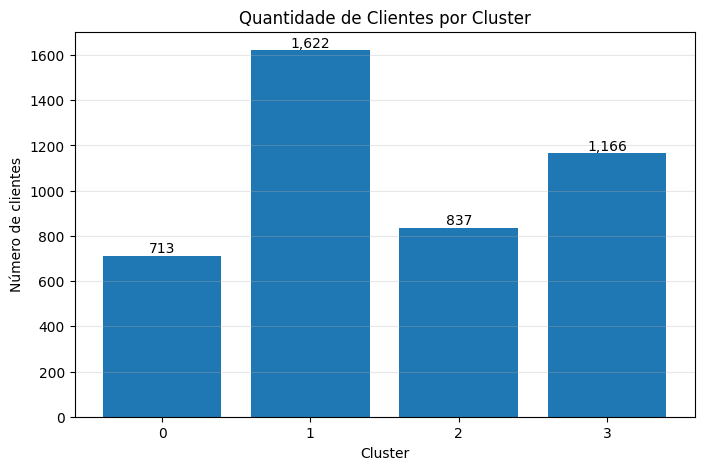

In [72]:
# Quantidade de clientes por cluster

cluster_counts = rfm.groupby(kmeans_labels).size()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values
)

plt.title('Quantidade de Clientes por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Número de clientes')

# Adicionar valores nas barras
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height):,}',
        ha='center',
        va='bottom'
    )

plt.grid(axis='y', alpha=0.3)
plt.show()

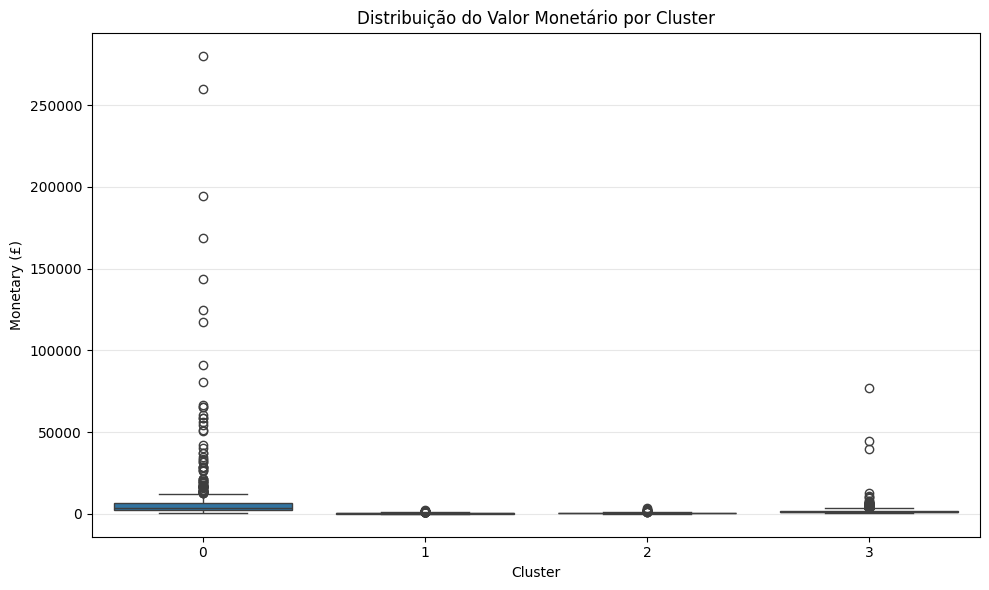

In [73]:
# Preparar dados para o boxplot
rfm_boxplot = rfm.copy()
rfm_boxplot['Cluster'] = kmeans_labels

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=rfm_boxplot,
    x='Cluster',
    y='Monetary'
)

plt.title('Distribuição do Valor Monetário por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Monetary (£)')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

O boxplot evidencia diferenças expressivas na distribuição do valor monetário entre os segmentos. O Cluster 0 apresenta os maiores valores e uma quantidade significativa de outliers de alto valor, indicando a presença de clientes com contribuição financeira excepcional. Os demais clusters concentram a maior parte das observações em valores monetários significativamente menores. A assimetria observada reforça a importância da transformação logarítmica aplicada anteriormente às variáveis RFM.

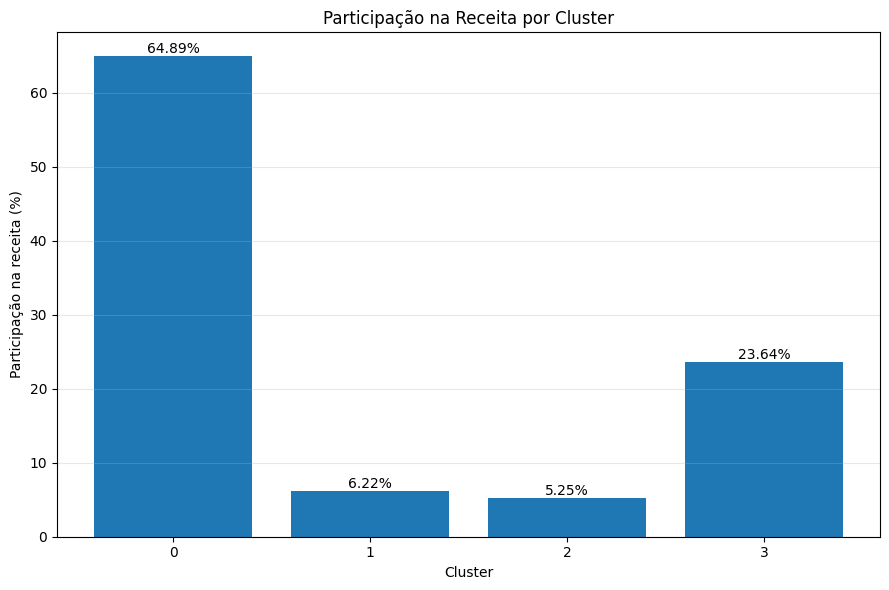

In [74]:
# Receita total e participação por cluster

business_kmeans = rfm.copy()
business_kmeans['Cluster'] = kmeans_labels

revenue_by_cluster = (
    business_kmeans
    .groupby('Cluster')['Monetary']
    .sum()
)

revenue_share = (
    revenue_by_cluster /
    revenue_by_cluster.sum() * 100
)

plt.figure(figsize=(9, 6))

bars = plt.bar(
    revenue_share.index.astype(str),
    revenue_share.values
)

plt.title('Participação na Receita por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Participação na receita (%)')

for bar, value in zip(bars, revenue_share.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f'{value:.2f}%',
        ha='center',
        va='bottom'
    )

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Concentração de receita: A distribuição da receita evidencia uma forte concentração de valor em determinados segmentos. O Cluster 0 reúne 16,44% dos clientes, mas responde por 64,89% da receita total, indicando elevada concentração de valor financeiro nesse grupo. Em contraste, o Cluster 1 concentra 37,39% dos clientes, mas contribui com apenas 6,22% da receita. Esse resultado demonstra a importância de estratégias diferenciadas de retenção, desenvolvimento e reativação de clientes.

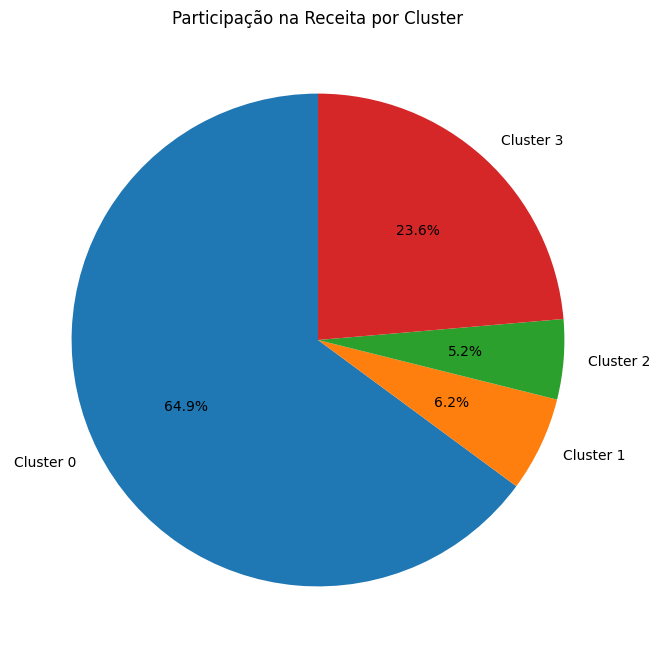

In [75]:
# Pie chart da participação na receita por cluster

plt.figure(figsize=(8, 8))

plt.pie(
    revenue_share.values,
    labels=[
        f'Cluster {cluster}'
        for cluster in revenue_share.index
    ],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Participação na Receita por Cluster')

plt.show()

In [76]:
# Tabela consolidada dos segmentos K-Means

final_profile = rfm.copy()
final_profile['Cluster'] = kmeans_labels

final_profile = final_profile.groupby('Cluster').agg(
    Clientes=('CustomerID', 'count'),
    Recencia_Media=('Recency', 'mean'),
    Frequencia_Media=('Frequency', 'mean'),
    Monetary_Medio=('Monetary', 'mean'),
    Receita_Total=('Monetary', 'sum')
).reset_index()

# Percentual de clientes
final_profile['% Clientes'] = (
    final_profile['Clientes'] /
    final_profile['Clientes'].sum() * 100
)

# Percentual da receita
final_profile['% Receita'] = (
    final_profile['Receita_Total'] /
    final_profile['Receita_Total'].sum() * 100
)

# Ordenar pelo cluster
final_profile = final_profile.sort_values('Cluster')

final_profile.round(2)

,Cluster,Clientes,Recencia_Media,Frequencia_Media,Monetary_Medio,Receita_Total,% Clientes,% Receita
0,0,713,12.17,13.75,8088.02,5766757.07,16.44,64.89
1,1,1622,181.51,1.32,341.00,553099.77,37.39,6.22
2,2,837,17.70,2.19,557.32,466479.03,19.29,5.25
3,3,1166,71.64,4.08,1801.78,2100873.02,26.88,23.64


In [77]:
# Nome dos segmentos para análise de negócio

segment_names = {
    0: 'Clientes de Alto Valor',
    1: 'Clientes Inativos',
    2: 'Clientes Recentes em Desenvolvimento',
    3: 'Clientes de Valor Intermediário'
}

final_profile['Segmento'] = final_profile['Cluster'].map(segment_names)

final_profile[
    [
        'Cluster',
        'Segmento',
        'Clientes',
        '% Clientes',
        'Recencia_Media',
        'Frequencia_Media',
        'Monetary_Medio',
        'Receita_Total',
        '% Receita'
    ]
].round(2)

,Cluster,Segmento,Clientes,% Clientes,Recencia_Media,Frequencia_Media,Monetary_Medio,Receita_Total,% Receita
0,0,Clientes de Alto Valor,713,16.44,12.17,13.75,8088.02,5766757.07,64.89
1,1,Clientes Inativos,1622,37.39,181.51,1.32,341.00,553099.77,6.22
2,2,Clientes Recentes em Desenvolvimento,837,19.29,17.70,2.19,557.32,466479.03,5.25
3,3,Clientes de Valor Intermediário,1166,26.88,71.64,4.08,1801.78,2100873.02,23.64


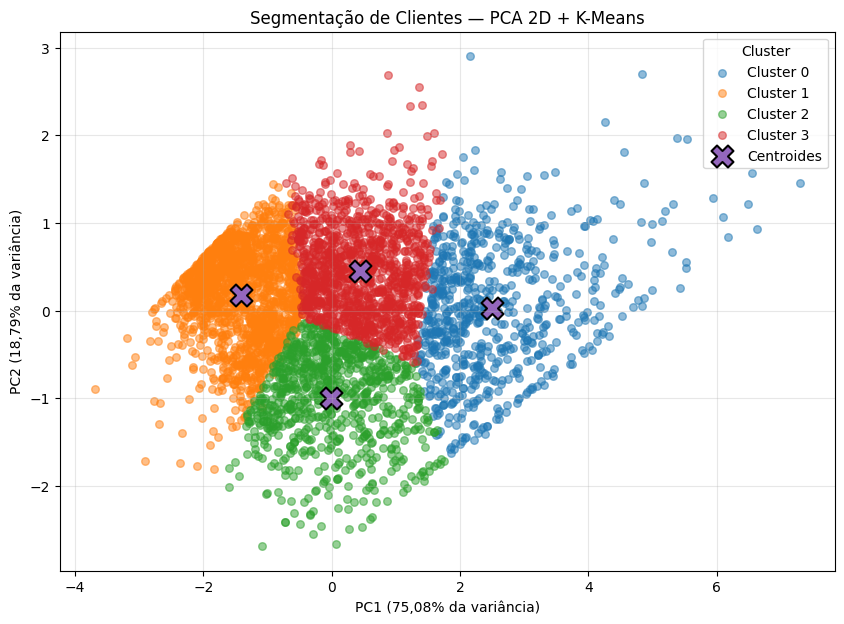

In [78]:
# PCA 2D com centroides do K-Means

centroids_pca_2d = pca_2d.transform(kmeans_final.cluster_centers_)

plt.figure(figsize=(10, 7))

for cluster in sorted(pca_df['Cluster'].unique()):
    cluster_data = pca_df[pca_df['Cluster'] == cluster]

    plt.scatter(
        cluster_data['PC1'],
        cluster_data['PC2'],
        label=f'Cluster {cluster}',
        alpha=0.5,
        s=30
    )

# Centroides
plt.scatter(
    centroids_pca_2d[:, 0],
    centroids_pca_2d[:, 1],
    marker='X',
    s=250,
    edgecolor='black',
    linewidth=1.5,
    label='Centroides'
)

plt.xlabel('PC1 (75,08% da variância)')
plt.ylabel('PC2 (18,79% da variância)')
plt.title('Segmentação de Clientes — PCA 2D + K-Means')
plt.legend(title='Cluster')
plt.grid(True, alpha=0.3)

plt.show()

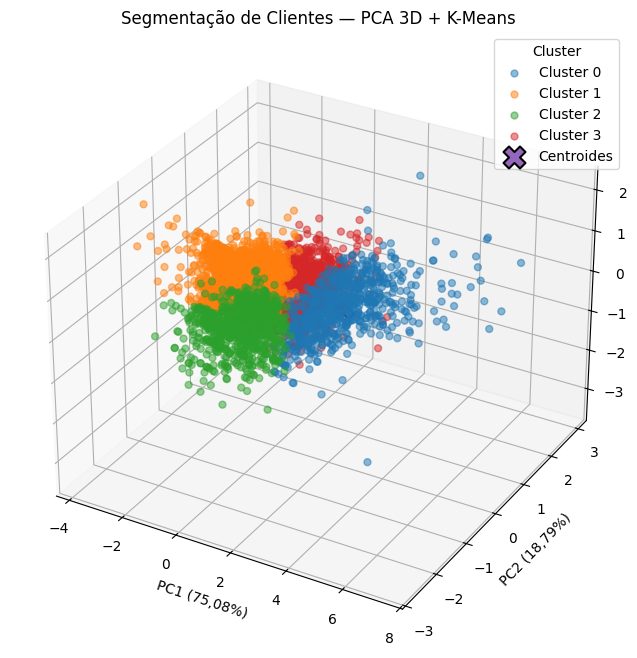

In [79]:
# PCA 3D com centroides do K-Means

centroids_pca_3d = pca_3d.transform(kmeans_final.cluster_centers_)

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection='3d')

# Clientes
for cluster in sorted(pca_3d_df['Cluster'].unique()):
    cluster_data = pca_3d_df[pca_3d_df['Cluster'] == cluster]

    ax.scatter(
        cluster_data['PC1'],
        cluster_data['PC2'],
        cluster_data['PC3'],
        label=f'Cluster {cluster}',
        alpha=0.5,
        s=25
    )

# Centroides
ax.scatter(
    centroids_pca_3d[:, 0],
    centroids_pca_3d[:, 1],
    centroids_pca_3d[:, 2],
    marker='X',
    s=250,
    edgecolor='black',
    linewidth=1.5,
    label='Centroides'
)

ax.set_xlabel('PC1 (75,08%)')
ax.set_ylabel('PC2 (18,79%)')
ax.set_zlabel('PC3 (6,13%)')

ax.set_title('Segmentação de Clientes — PCA 3D + K-Means')
ax.legend(title='Cluster')

plt.show()

## Insights e Oportunidades de Negócio

A segmentação realizada por meio do K-Means identificou quatro grupos de clientes com comportamentos distintos em relação à recência, frequência de compras e valor monetário.

### Principais insights

1. **Alta concentração de receita:** o segmento Clientes de Alto Valor representa 16,44% da base, mas concentra 64,89% da receita total. Esse resultado evidencia a importância da retenção desses clientes para a sustentabilidade da receita.

2. **Grande base de clientes inativos:** Clientes Inativos representam 37,39% da base, mas contribuem com apenas 6,22% da receita. A recência média de 181,51 dias indica baixa atividade recente.

3. **Oportunidade de desenvolvimento:** Clientes Recentes em Desenvolvimento correspondem a 19,29% da base e apresentam recência média de apenas 17,70 dias, mas frequência média de 2,19 compras. Esse grupo apresenta potencial para aumento de recorrência e valor.

4. **Segmento de valor intermediário:** Clientes de Valor Intermediário representam 26,88% dos clientes e 23,64% da receita, apresentando frequência média de 4,08 compras e valor monetário médio de £1.801,78.

### Recomendações

- **Retenção dos Clientes de Alto Valor:** desenvolver ações de fidelização, benefícios personalizados e estratégias de retenção para proteger o segmento responsável pela maior parcela da receita.

- **Reativação dos Clientes Inativos:** desenvolver campanhas direcionadas de reativação e incentivos para estimular uma nova compra e recuperar parte do valor potencial dessa base.

- **Desenvolvimento dos Clientes Recentes:** utilizar ações de pós-venda, recomendações personalizadas e incentivos à próxima compra para aumentar a frequência e o valor desses clientes.

## Conclusão

A análise de segmentação de clientes foi realizada utilizando o modelo RFM, considerando Recency, Frequency e Monetary como variáveis de comportamento de compra. Após a limpeza dos dados, transformação logarítmica e padronização, foram avaliados diferentes métodos de agrupamento, incluindo K-Means, agrupamento hierárquico e Gaussian Mixture Model (GMM).

O K-Means com quatro clusters apresentou uma segmentação com grupos de comportamento distintos e estáveis, permitindo identificar quatro segmentos de negócio: Clientes de Alto Valor, Clientes Inativos, Clientes Recentes em Desenvolvimento e Clientes de Valor Intermediário.

Os resultados demonstraram uma forte concentração de receita: o segmento de Clientes de Alto Valor representa 16,44% dos clientes, mas responde por 64,89% da receita. Em contraste, os Clientes Inativos representam 37,39% da base e contribuem com apenas 6,22% da receita.

A utilização de PCA permitiu representar os dados em duas dimensões preservando 93,87% da variância, facilitando a visualização da estrutura dos clusters. As análises complementares por meio de radar chart, heatmap e gráficos financeiros reforçaram as diferenças entre os segmentos.

Como principal contribuição, a segmentação permite relacionar técnicas de aprendizado não supervisionado a decisões de negócio, possibilitando estratégias diferenciadas de retenção, reativação e desenvolvimento de clientes.

## Dashboard Interativo

O dashboard apresenta uma visão executiva da segmentação de clientes, reunindo indicadores de volume, valor financeiro e comportamento dos segmentos identificados pelo modelo K-Means.

In [80]:
# Preparação dos dados para o dashboard

import plotly.express as px
import plotly.graph_objects as go

dashboard_data = final_profile.copy()

dashboard_data

,Cluster,Clientes,Recencia_Media,Frequencia_Media,Monetary_Medio,Receita_Total,% Clientes,% Receita,Segmento
0,0,713,12.171108,13.751753,8088.018331,5766757.070,16.436146,64.888281,Clientes de Alto Valor
1,1,1622,181.506782,1.316893,340.998626,553099.771,37.390503,6.223549,Clientes Inativos
2,2,837,17.698925,2.192354,557.322616,466479.030,19.294606,5.248881,Clientes Recentes em Desenvolvimento
3,3,1166,71.635506,4.078902,1801.777893,2100873.023,26.878746,23.639289,Clientes de Valor Intermediário


In [81]:
# KPIs principais do dashboard

total_clientes = int(dashboard_data['Clientes'].sum())
receita_total = dashboard_data['Receita_Total'].sum()
numero_segmentos = dashboard_data['Cluster'].nunique()

alto_valor_receita = dashboard_data.loc[
    dashboard_data['Cluster'] == 0,
    '% Receita'
].iloc[0]

print(f"Total de clientes: {total_clientes:,}")
print(f"Receita total: £{receita_total:,.2f}")
print(f"Número de segmentos: {numero_segmentos}")
print(f"Receita do segmento de Alto Valor: {alto_valor_receita:.2f}%")

Total de clientes: 4,338
Receita total: £8,887,208.89
Número de segmentos: 4
Receita do segmento de Alto Valor: 64.89%


In [82]:
# Cards principais do dashboard

fig = go.Figure()

fig.add_trace(go.Indicator(
    mode="number",
    value=total_clientes,
    title={"text": "Total de Clientes"},
    number={"valueformat": ","},
    domain={"x": [0.00, 0.25], "y": [0, 1]}
))

fig.add_trace(go.Indicator(
    mode="number",
    value=receita_total,
    title={"text": "Receita Total (£)"},
    number={"prefix": "£", "valueformat": ",.2f"},
    domain={"x": [0.25, 0.50], "y": [0, 1]}
))

fig.add_trace(go.Indicator(
    mode="number",
    value=numero_segmentos,
    title={"text": "Segmentos"},
    domain={"x": [0.50, 0.75], "y": [0, 1]}
))

fig.add_trace(go.Indicator(
    mode="number",
    value=alto_valor_receita,
    title={"text": "Receita — Alto Valor (%)"},
    number={"suffix": "%", "valueformat": ".2f"},
    domain={"x": [0.75, 1.00], "y": [0, 1]}
))

fig.update_layout(
    title="Dashboard — Segmentação de Clientes",
    height=300
)

fig.show()

In [83]:
# Clientes por segmento

fig_clientes = px.bar(
    dashboard_data,
    x='Segmento',
    y='Clientes',
    text='Clientes',
    hover_data={
        '% Clientes': ':.2f'
    },
    title='Quantidade de Clientes por Segmento'
)

fig_clientes.update_traces(
    textposition='outside'
)

fig_clientes.update_layout(
    xaxis_title='Segmento',
    yaxis_title='Número de Clientes',
    height=500
)

fig_clientes.show()

In [84]:
# Receita total por segmento

fig_receita = px.bar(
    dashboard_data,
    x='Segmento',
    y='Receita_Total',
    text='% Receita',
    hover_data={
        'Receita_Total': ':,.2f',
        '% Receita': ':.2f'
    },
    title='Receita Total por Segmento'
)

fig_receita.update_traces(
    texttemplate='%{text:.2f}%',
    textposition='outside'
)

fig_receita.update_layout(
    xaxis_title='Segmento',
    yaxis_title='Receita Total (£)',
    yaxis_tickprefix='£',
    yaxis_tickformat=',.0f',
    height=500
)

fig_receita.show()

In [85]:
# Perfil RFM dos segmentos

rfm_dashboard = rfm_scaled.copy()
rfm_dashboard['Cluster'] = kmeans_labels
rfm_dashboard['Segmento'] = rfm_dashboard['Cluster'].map(
    dict(zip(dashboard_data['Cluster'], dashboard_data['Segmento']))
)

rfm_profile = rfm_dashboard.groupby('Segmento')[
    ['Recency', 'Frequency', 'Monetary']
].mean().reset_index()

rfm_long = rfm_profile.melt(
    id_vars='Segmento',
    var_name='Métrica',
    value_name='Valor Padronizado'
)

fig_rfm = px.bar(
    rfm_long,
    x='Segmento',
    y='Valor Padronizado',
    color='Métrica',
    barmode='group',
    title='Perfil RFM Padronizado por Segmento',
    hover_data={'Valor Padronizado': ':.2f'}
)

fig_rfm.update_layout(
    xaxis_title='Segmento',
    yaxis_title='Valor Padronizado',
    height=500
)

fig_rfm.show()

In [87]:
# PCA 2D interativo com clusters e centroides

# Transformar os clientes para o espaço PCA
pca_coords = pca_2d.transform(rfm_scaled)

pca_dashboard = pd.DataFrame(
    pca_coords,
    columns=['PC1', 'PC2']
)

pca_dashboard['Cluster'] = kmeans_labels

pca_dashboard['Segmento'] = pca_dashboard['Cluster'].map(
    dict(zip(dashboard_data['Cluster'], dashboard_data['Segmento']))
)

fig_pca = px.scatter(
    pca_dashboard,
    x='PC1',
    y='PC2',
    color='Segmento',
    title='PCA 2D — Segmentação dos Clientes',
    opacity=0.65,
    hover_data=['Cluster'],
    labels={
        'PC1': 'Componente Principal 1',
        'PC2': 'Componente Principal 2'
    }
)

# Adicionar centroides
centroides_pca = pd.DataFrame(
    centroids_pca_2d,
    columns=['PC1', 'PC2']
)

centroides_pca['Cluster'] = range(len(centroides_pca))
centroides_pca['Segmento'] = centroides_pca['Cluster'].map(
    dict(zip(dashboard_data['Cluster'], dashboard_data['Segmento']))
)

fig_pca.add_trace(
    go.Scatter(
        x=centroides_pca['PC1'],
        y=centroides_pca['PC2'],
        mode='markers+text',
        marker=dict(
            size=18,
            symbol='x'
        ),
        text=centroides_pca['Segmento'],
        textposition='top center',
        name='Centroides'
    )
)

fig_pca.update_layout(
    height=600,
    legend_title='Segmento'
)

fig_pca.show()

In [88]:
# Distribuição do valor monetário por segmento

boxplot_data = rfm.copy()
boxplot_data['Cluster'] = kmeans_labels

boxplot_data['Segmento'] = boxplot_data['Cluster'].map(
    dict(zip(dashboard_data['Cluster'], dashboard_data['Segmento']))
)

fig_box = px.box(
    boxplot_data,
    x='Segmento',
    y='Monetary',
    color='Segmento',
    points=False,
    title='Distribuição do Valor Monetário por Segmento',
    labels={
        'Segmento': 'Segmento',
        'Monetary': 'Valor Monetário (£)'
    }
)

fig_box.update_layout(
    height=550,
    showlegend=False,
    yaxis_tickprefix='£',
    yaxis_tickformat=',.0f'
)

fig_box.show()

In [89]:
# Participação de cada segmento na receita

fig_pizza = px.pie(
    dashboard_data,
    names='Segmento',
    values='Receita_Total',
    title='Participação dos Segmentos na Receita',
    hole=0.35,
    hover_data={
        '% Receita': ':.2f'
    }
)

fig_pizza.update_traces(
    textposition='inside',
    textinfo='percent'
)

fig_pizza.update_layout(
    height=550
)

fig_pizza.show()

In [90]:
# Relação entre Recência e Valor Monetário

scatter_data = rfm.copy()
scatter_data['Cluster'] = kmeans_labels

scatter_data['Segmento'] = scatter_data['Cluster'].map(
    dict(zip(dashboard_data['Cluster'], dashboard_data['Segmento']))
)

fig_scatter = px.scatter(
    scatter_data,
    x='Recency',
    y='Monetary',
    color='Segmento',
    log_y=True,
    opacity=0.65,
    title='Recência × Valor Monetário por Segmento',
    labels={
        'Recency': 'Recência (dias)',
        'Monetary': 'Valor Monetário (£)'
    },
    hover_data=['Frequency']
)

fig_scatter.update_layout(
    height=550,
    legend_title='Segmento'
)

fig_scatter.show()

In [91]:
from plotly.subplots import make_subplots

# Dashboard executivo final

fig_dashboard = make_subplots(
    rows=3,
    cols=2,
    specs=[
        [
            {"type": "indicator"},
            {"type": "indicator"}
        ],
        [
            {"type": "bar"},
            {"type": "bar"}
        ],
        [
            {"type": "bar"},
            {"type": "pie"}
        ]
    ],
    subplot_titles=(
        "Total de Clientes",
        "Receita Total",
        "Clientes por Segmento",
        "Receita por Segmento",
        "Perfil RFM",
        "Participação na Receita"
    ),
    vertical_spacing=0.12,
    horizontal_spacing=0.10
)

# =========================
# KPIs
# =========================

fig_dashboard.add_trace(
    go.Indicator(
        mode="number",
        value=total_clientes,
        number={"valueformat": ","}
    ),
    row=1,
    col=1
)

fig_dashboard.add_trace(
    go.Indicator(
        mode="number",
        value=receita_total,
        number={"prefix": "£", "valueformat": ",.2f"}
    ),
    row=1,
    col=2
)

# =========================
# Clientes por segmento
# =========================

fig_dashboard.add_trace(
    go.Bar(
        x=dashboard_data['Segmento'],
        y=dashboard_data['Clientes'],
        text=dashboard_data['Clientes'],
        textposition='outside',
        name='Clientes'
    ),
    row=2,
    col=1
)

# =========================
# Receita por segmento
# =========================

fig_dashboard.add_trace(
    go.Bar(
        x=dashboard_data['Segmento'],
        y=dashboard_data['Receita_Total'],
        text=dashboard_data['% Receita'],
        texttemplate='%{text:.2f}%',
        textposition='outside',
        name='Receita'
    ),
    row=2,
    col=2
)

# =========================
# Perfil RFM
# =========================

for metrica in ['Recency', 'Frequency', 'Monetary']:

    dados_metrica = rfm_long[
        rfm_long['Métrica'] == metrica
    ]

    fig_dashboard.add_trace(
        go.Bar(
            x=dados_metrica['Segmento'],
            y=dados_metrica['Valor Padronizado'],
            name=metrica
        ),
        row=3,
        col=1
    )

# =========================
# Receita — Pizza
# =========================

fig_dashboard.add_trace(
    go.Pie(
        labels=dashboard_data['Segmento'],
        values=dashboard_data['Receita_Total'],
        hole=0.4,
        textinfo='percent'
    ),
    row=3,
    col=2
)

# =========================
# Layout
# =========================

fig_dashboard.update_layout(
    title={
        'text': 'Dashboard Executivo — Segmentação de Clientes',
        'x': 0.5
    },
    height=1200,
    showlegend=True
)

fig_dashboard.update_yaxes(
    title_text='Número de Clientes',
    row=2,
    col=1
)

fig_dashboard.update_yaxes(
    title_text='Receita (£)',
    tickprefix='£',
    tickformat=',.0f',
    row=2,
    col=2
)

fig_dashboard.update_yaxes(
    title_text='Valor Padronizado',
    row=3,
    col=1
)

fig_dashboard.show()

In [92]:
# Ajuste visual do dashboard executivo

fig_dashboard.update_layout(
    title={
        'text': 'Dashboard Executivo — Segmentação de Clientes',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 24}
    },
    height=1400,
    margin=dict(t=100, b=100, l=80, r=80),
    showlegend=True
)

# Melhorar os nomes dos segmentos nos gráficos
fig_dashboard.update_xaxes(
    tickangle=-25,
    tickfont=dict(size=10),
    row=2,
    col=1
)

fig_dashboard.update_xaxes(
    tickangle=-25,
    tickfont=dict(size=10),
    row=2,
    col=2
)

fig_dashboard.update_xaxes(
    tickangle=-25,
    tickfont=dict(size=10),
    row=3,
    col=1
)

# Mostrar novamente
fig_dashboard.show()